In [ ]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [11]:
df = pd.read_csv("finalesta_akher.csv")
print(df.shape)
df.head()

(383330, 32)


,index_right,sum(Weight_Day),label,Time_O_tan_2_norm,first(Day_EMG_encoded)_norm,first(Date_EMG_encoded)_norm,avg(ID_Trip_Days)_norm,avg(Duration)_norm,avg(temp)_norm,avg(rhum)_norm,...,sum(Weight_Day)_norm,sum(distance_km)_norm,first(fclass_encoded)_norm,PRO_CAT_norm,length_norm,first(Day_Type)_target_norm,first(Zone_O)_target_norm,mode(Zone_D)_target_norm,mode(Purpose_O)_target_norm,mode(Purpose_D)_target_norm
0,0,388.825727,0,1.000000,0.000000,0.393548,0.277778,0.098814,0.398693,0.831169,...,0.000127,0.000000,0.192308,0.142857,0.003170,0.706335,0.0,0.0,0.000000,0.333460
1,0,767.438335,1,0.913043,0.000000,0.096774,0.055556,0.086957,0.411765,1.000000,...,0.000267,0.000000,0.192308,0.714286,0.003170,0.706335,0.0,0.0,0.256514,0.494038
2,1,7747.851594,2,1.000000,0.666667,0.819355,0.166667,0.088933,0.601307,0.493506,...,0.002839,0.004062,0.115385,0.285714,0.003385,0.706335,0.0,0.0,0.262538,0.333460
3,2,7944.068253,2,0.304348,0.000000,0.051613,0.166667,0.019763,0.683007,0.766234,...,0.002912,0.003829,0.038462,0.857143,0.011206,0.706335,0.0,0.0,0.256514,0.494038
4,2,1835.954863,1,0.086957,0.333333,0.896774,0.111111,0.071146,0.833333,0.337662,...,0.000661,0.004433,0.038462,0.285714,0.011206,0.706335,0.0,0.0,0.239530,0.333460


In [12]:
roads = [
  201733,
  447037,
  849514,
  723734,
  566656
]

df = df[~df['index_right'].isin(roads)]

In [13]:
df.columns
df['label'].unique()
df['label'].value_counts()
for col, dtype in df.dtypes.items():
    print(f"{col}  : {dtype}")
df.isnull().sum()

index_right  : int64
sum(Weight_Day)  : float64
label  : int64
Time_O_tan_2_norm  : float64
first(Day_EMG_encoded)_norm  : float64
first(Date_EMG_encoded)_norm  : float64
avg(ID_Trip_Days)_norm  : float64
avg(Duration)_norm  : float64
avg(temp)_norm  : float64
avg(rhum)_norm  : float64
avg(prcp)_norm  : float64
avg(SPEED)_norm  : float64
first(Time_O_sin)_norm  : float64
first(Time_O_cos)_norm  : float64
first(Time_D_sin)_norm  : float64
first(Time_D_cos)_norm  : float64
Number of GPS points_norm  : float64
Number of people having one or more car_norm  : float64
Number of people having one or more BIKE_norm  : float64
Number of people having one or more ELECT_SCOOTER_norm  : float64
Number of people having one or more TWO_WHEELER_norm  : float64
(sum((AGE * Weight_Day)) / sum(Weight_Day))_norm  : float64
sum(Weight_Day)_norm  : float64
sum(distance_km)_norm  : float64
first(fclass_encoded)_norm  : float64
PRO_CAT_norm  : float64
length_norm  : float64
first(Day_Type)_target_norm  : flo

index_right                                               0
sum(Weight_Day)                                           0
label                                                     0
Time_O_tan_2_norm                                         0
first(Day_EMG_encoded)_norm                               0
first(Date_EMG_encoded)_norm                              0
avg(ID_Trip_Days)_norm                                    0
avg(Duration)_norm                                        0
avg(temp)_norm                                            0
avg(rhum)_norm                                            0
avg(prcp)_norm                                            0
avg(SPEED)_norm                                           0
first(Time_O_sin)_norm                                    0
first(Time_O_cos)_norm                                    0
first(Time_D_sin)_norm                                    0
first(Time_D_cos)_norm                                    0
Number of GPS points_norm               

In [14]:
df.isnull().sum()

index_right                                               0
sum(Weight_Day)                                           0
label                                                     0
Time_O_tan_2_norm                                         0
first(Day_EMG_encoded)_norm                               0
first(Date_EMG_encoded)_norm                              0
avg(ID_Trip_Days)_norm                                    0
avg(Duration)_norm                                        0
avg(temp)_norm                                            0
avg(rhum)_norm                                            0
avg(prcp)_norm                                            0
avg(SPEED)_norm                                           0
first(Time_O_sin)_norm                                    0
first(Time_O_cos)_norm                                    0
first(Time_D_sin)_norm                                    0
first(Time_D_cos)_norm                                    0
Number of GPS points_norm               

In [15]:
df.corr()

,index_right,sum(Weight_Day),label,Time_O_tan_2_norm,first(Day_EMG_encoded)_norm,first(Date_EMG_encoded)_norm,avg(ID_Trip_Days)_norm,avg(Duration)_norm,avg(temp)_norm,avg(rhum)_norm,...,sum(Weight_Day)_norm,sum(distance_km)_norm,first(fclass_encoded)_norm,PRO_CAT_norm,length_norm,first(Day_Type)_target_norm,first(Zone_O)_target_norm,mode(Zone_D)_target_norm,mode(Purpose_O)_target_norm,mode(Purpose_D)_target_norm
index_right,1.000000,-0.060154,-0.067922,-0.028894,0.008438,0.015665,0.009585,0.033283,0.009049,-0.023451,...,-0.060154,-0.115517,-0.317453,-0.000550,-0.180150,0.011791,-0.259040,-0.257958,-0.043458,-0.030198
sum(Weight_Day),-0.060154,1.000000,0.274127,0.004563,0.000820,-0.049175,-0.001991,0.036835,0.060862,-0.000794,...,1.000000,0.378362,0.032675,0.053531,0.152293,0.017536,0.088921,0.087883,0.027688,0.022566
label,-0.067922,0.274127,1.000000,0.013255,0.013708,-0.072202,-0.001236,0.019482,0.078127,0.021062,...,0.274127,0.361471,0.008046,0.022563,0.174044,0.046964,0.096807,0.089144,0.067213,0.051430
Time_O_tan_2_norm,-0.028894,0.004563,0.013255,1.000000,-0.027410,-0.017082,-0.360739,-0.066425,-0.203547,0.339821,...,0.004563,0.018467,0.015118,-0.014111,0.014451,-0.007057,0.101820,0.094299,0.070518,-0.051093
first(Day_EMG_encoded)_norm,0.008438,0.000820,0.013708,-0.027410,1.000000,0.018223,-0.053555,0.079679,-0.000484,-0.002981,...,0.000820,0.011465,0.005261,-0.062105,0.009947,0.274872,-0.031820,-0.037625,0.013851,0.034772
first(Date_EMG_encoded)_norm,0.015665,-0.049175,-0.072202,-0.017082,0.018223,1.000000,0.043152,0.084336,-0.056965,-0.502093,...,-0.049175,-0.012795,-0.011726,0.008820,-0.000302,0.119747,-0.051015,-0.050384,0.033644,0.051456
avg(ID_Trip_Days)_norm,0.009585,-0.001991,-0.001236,-0.360739,-0.053555,0.043152,1.000000,-0.016732,0.081982,-0.180479,...,-0.001991,-0.008715,-0.013308,-0.029149,-0.003924,-0.025574,-0.031351,-0.011787,-0.097186,0.088367
avg(Duration)_norm,0.033283,0.036835,0.019482,-0.066425,0.079679,0.084336,-0.016732,1.000000,0.066814,-0.107991,...,0.036835,0.035697,0.037514,0.057858,-0.007500,0.043864,-0.133312,-0.126518,-0.052111,-0.005613
avg(temp)_norm,0.009049,0.060862,0.078127,-0.203547,-0.000484,-0.056965,0.081982,0.066814,1.000000,-0.349310,...,0.060862,0.004902,0.000408,0.099021,-0.007403,0.139814,-0.027471,-0.030983,-0.019248,0.021454
avg(rhum)_norm,-0.023451,-0.000794,0.021062,0.339821,-0.002981,-0.502093,-0.180479,-0.107991,-0.349310,1.000000,...,-0.000794,0.010737,0.006406,-0.084758,0.009570,-0.050786,0.074980,0.071058,0.041865,-0.051580


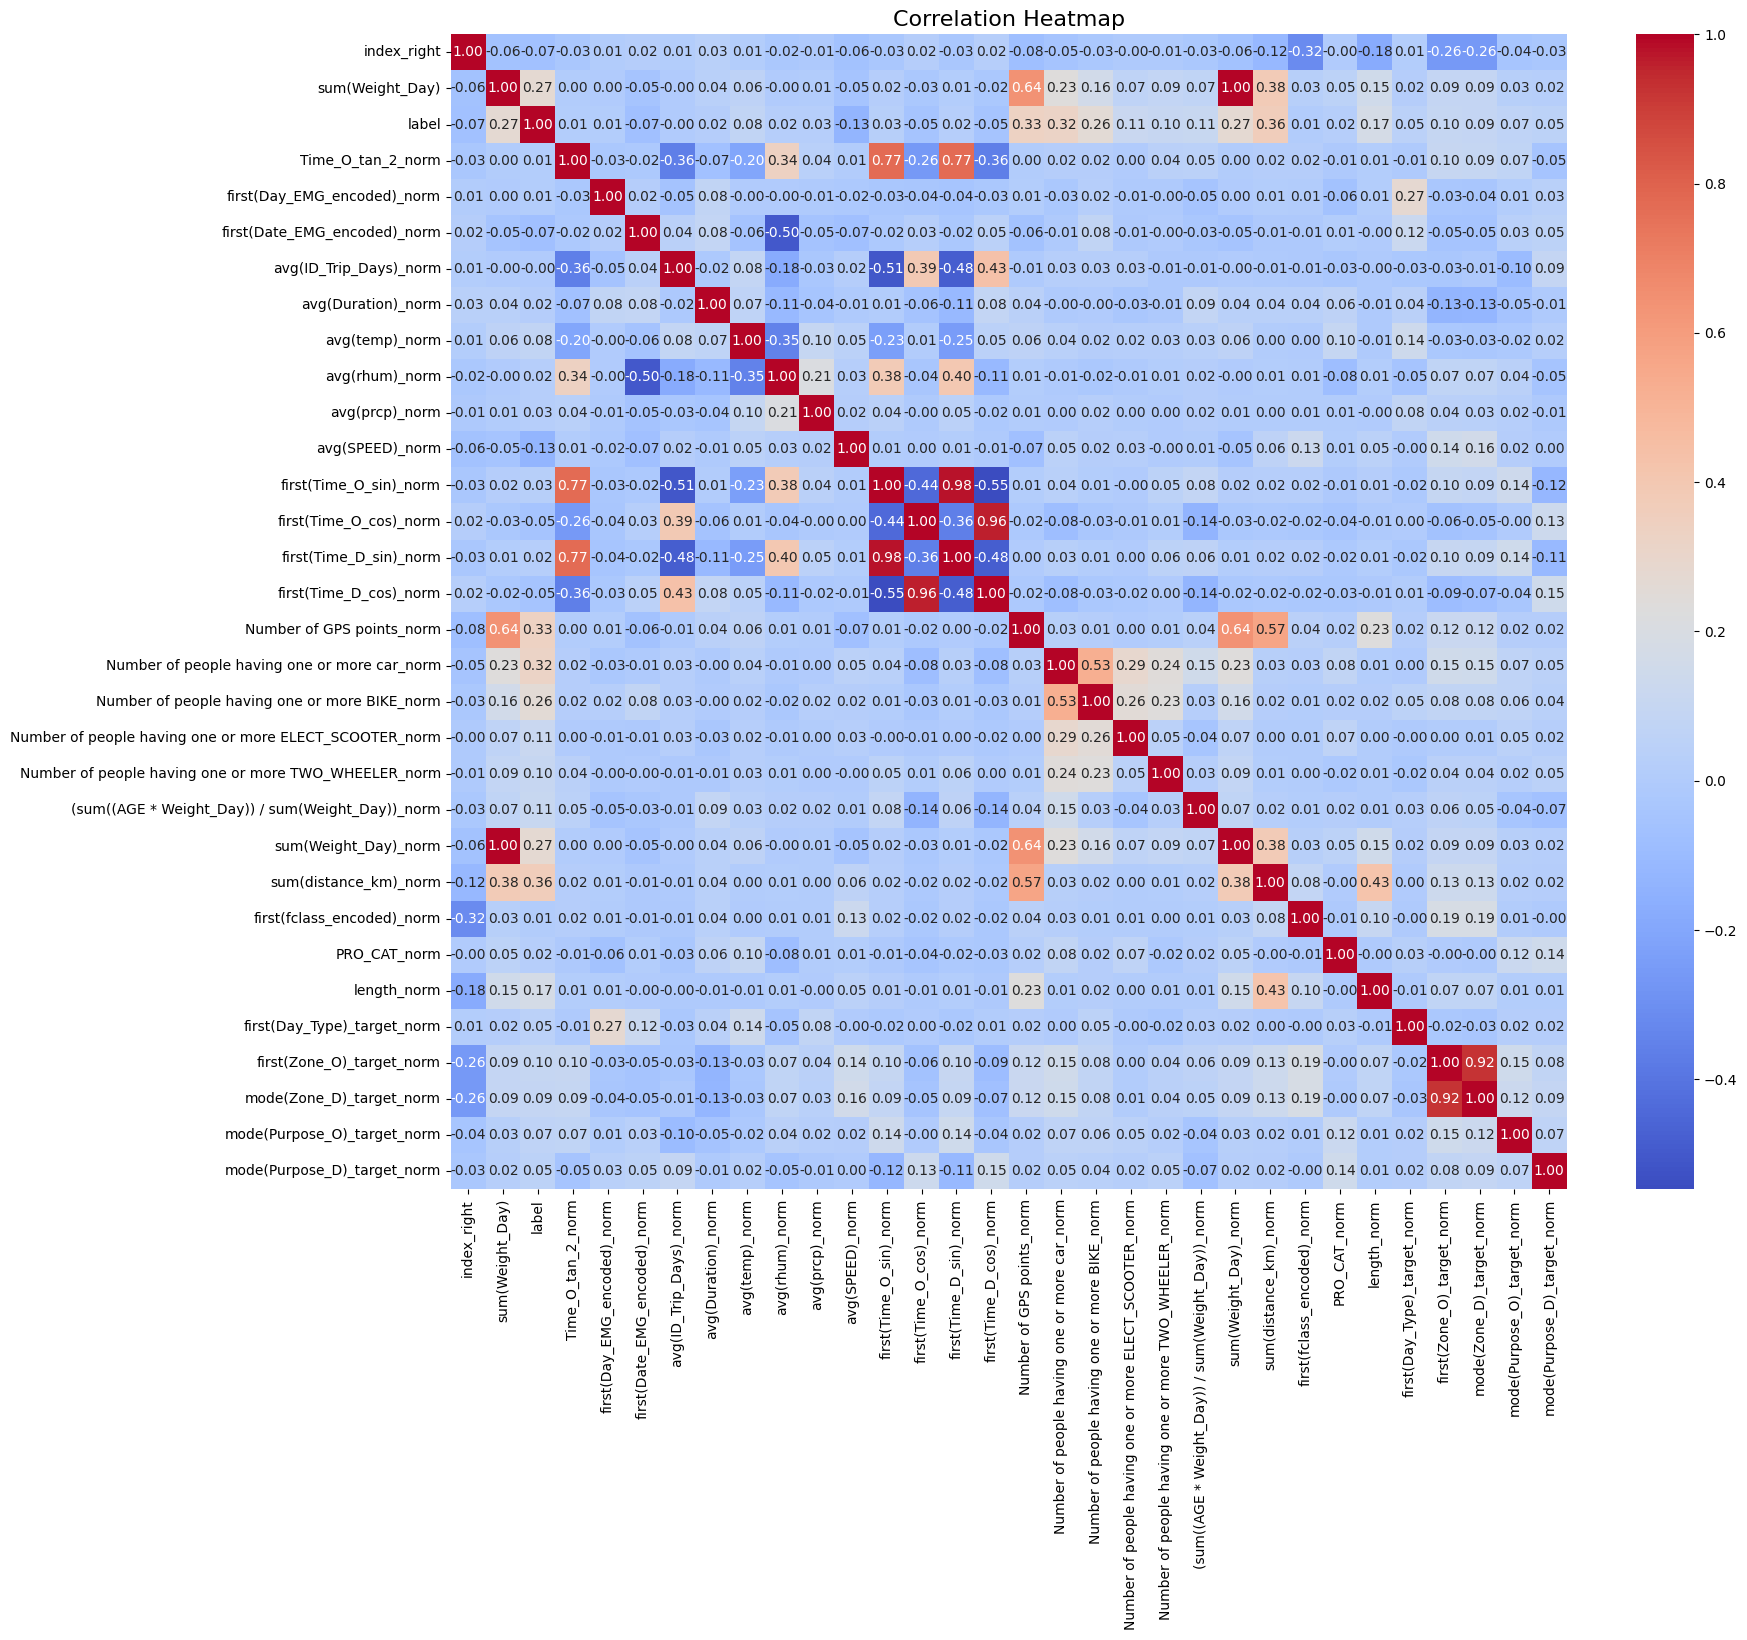

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18, 15))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

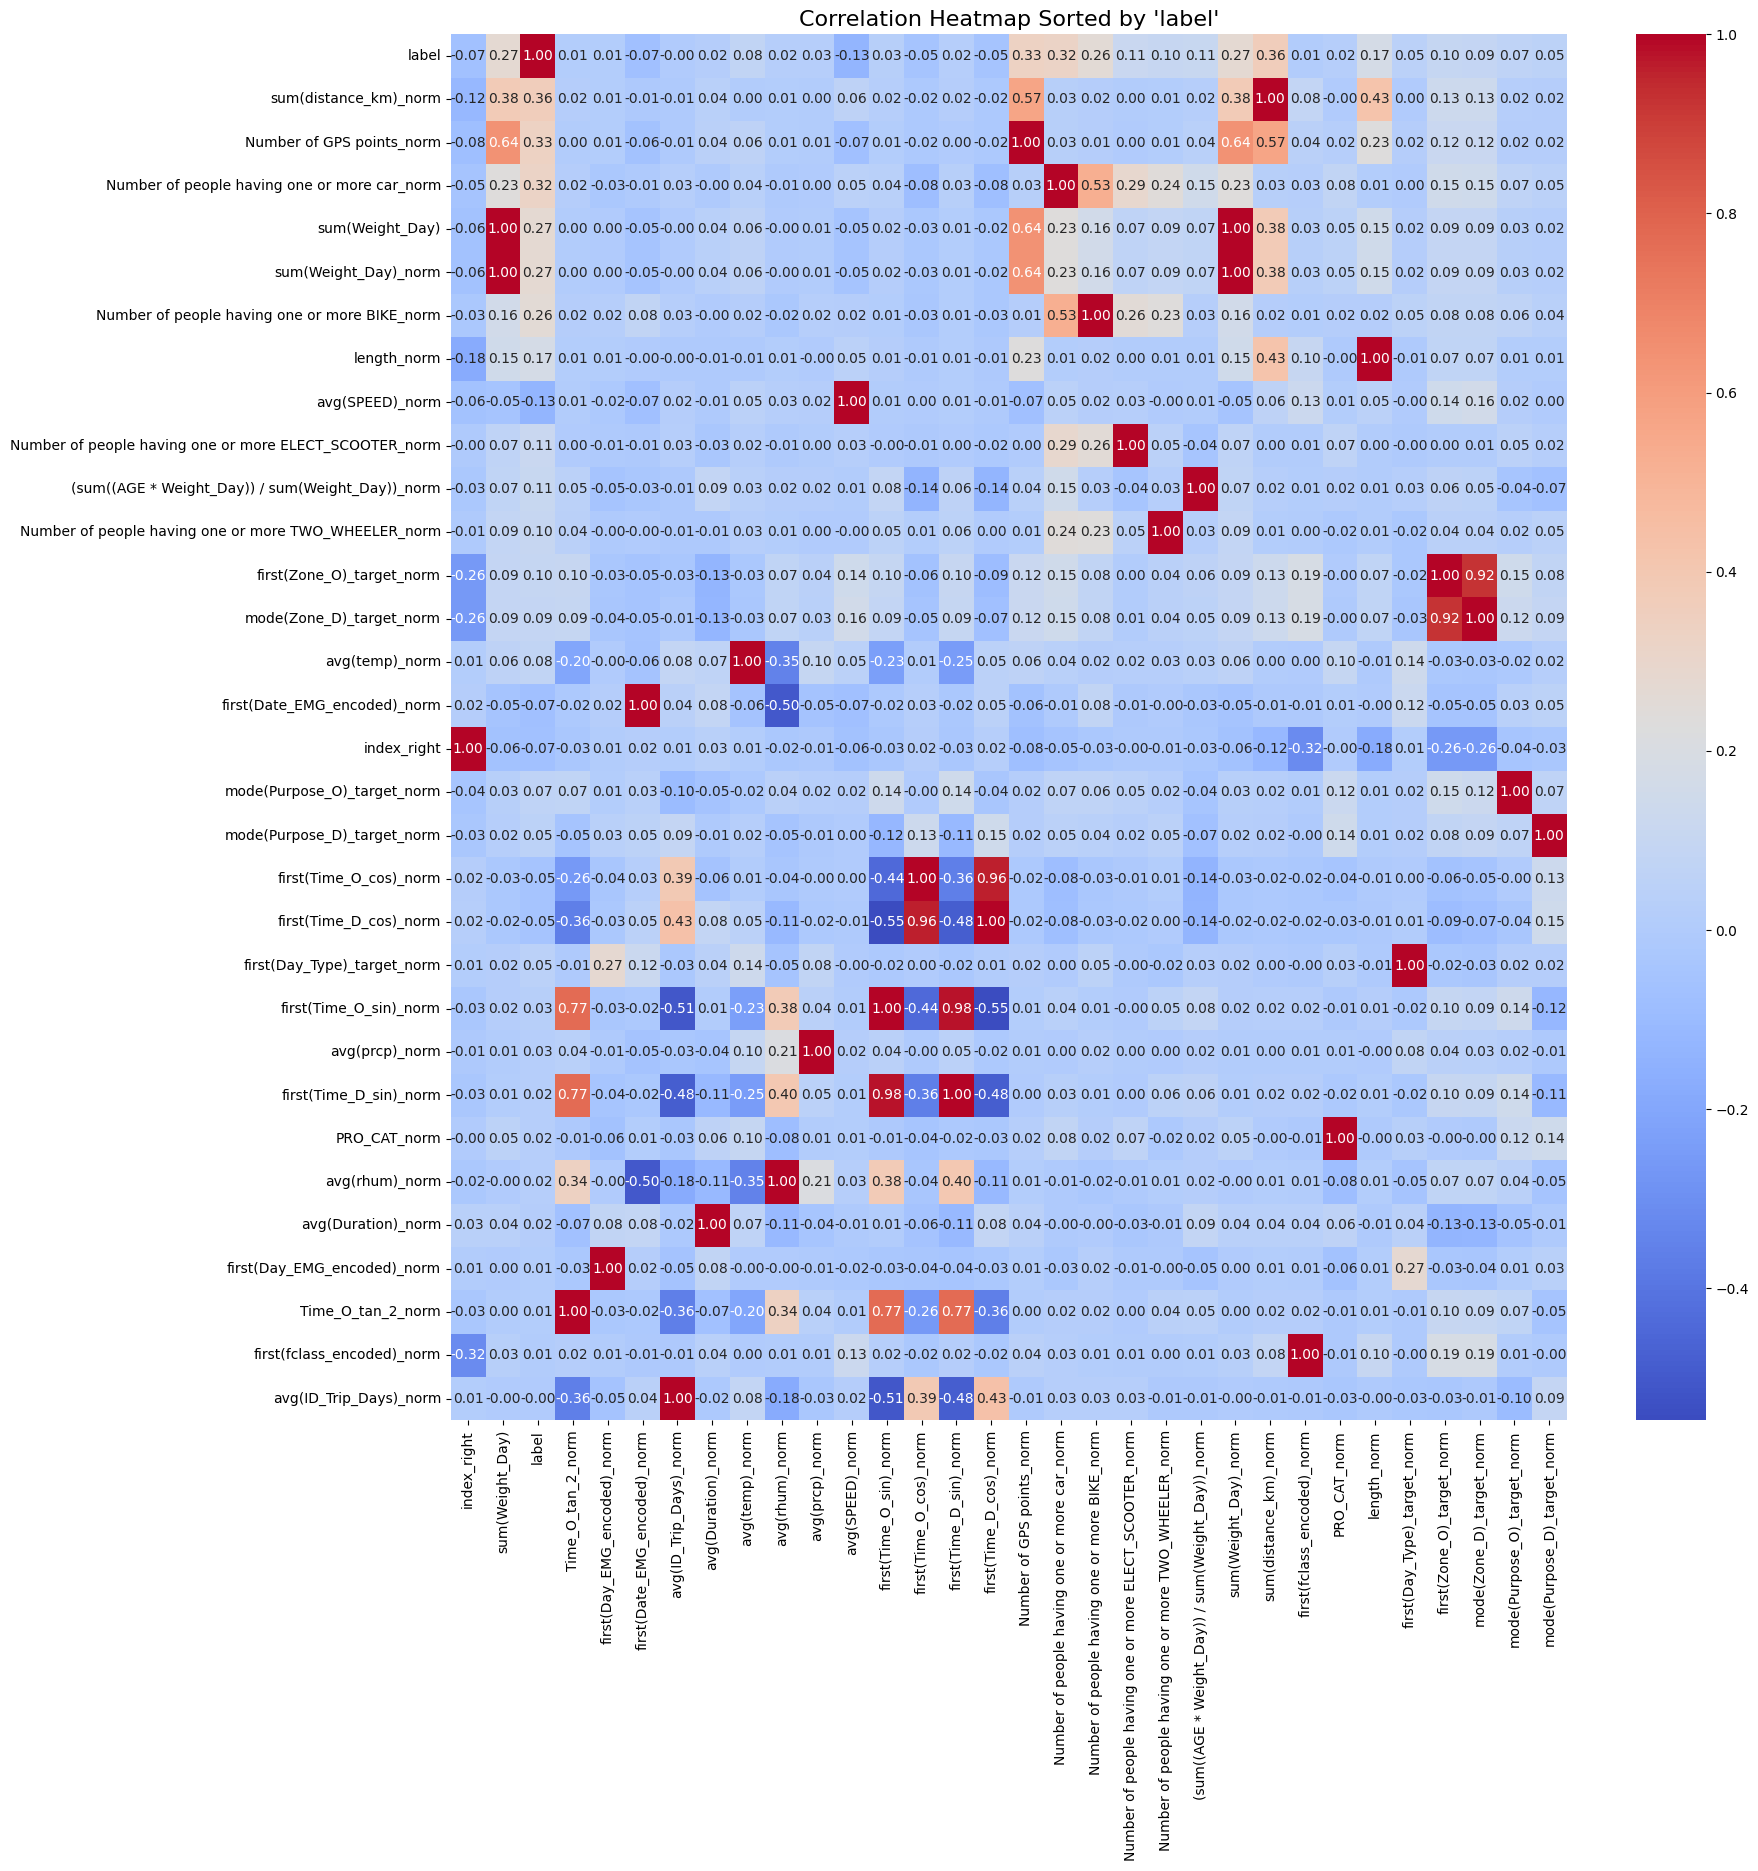

In [17]:
corr = df.corr(numeric_only=True)

corr_sorted = corr.loc[corr['label'].abs().sort_values(ascending=False).index]

plt.figure(figsize=(18, 18))
sns.heatmap(corr_sorted, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap Sorted by 'label'", fontsize=16)
plt.show()

In [18]:
df.shape

(383264, 32)

In [21]:
#df = df.drop(columns=["sum(Weight_Day)"])
#df = df.drop(columns=["Number of GPS points"])
#df = df.drop(columns=["sum(Weight_Day)", "Number of GPS points"])
#df = df.drop(columns=["sum(Weight_Day)_norm", "first(fclass_encoded)_norm"])

df = df.drop(columns=["sum(Weight_Day)_norm", "first(fclass_encoded)_norm","avg(ID_Trip_Days)_norm","avg(Duration)_norm","sum(Weight_Day)","index_right",
                      "first(Day_EMG_encoded)_norm"])

print(df.shape)

(383264, 25)


In [22]:
from sklearn.model_selection import train_test_split
import os

train, temp = train_test_split(df, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

os.makedirs("data/train", exist_ok=True)
os.makedirs("data/val", exist_ok=True)
os.makedirs("data/test", exist_ok=True)

train.to_csv("data/train/train.csv", index=False)
val.to_csv("data/val/val.csv", index=False)
test.to_csv("data/test/test.csv", index=False)

In [23]:
train_data = pd.read_csv("data/train/train.csv")
val_data = pd.read_csv("data/val/val.csv")
test_data = pd.read_csv("data/test/test.csv")
x_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
x_val = val_data.drop(columns=["label"])
y_val = val_data["label"]
x_test = test_data.drop(columns=["label"])
y_test = test_data["label"]
x_train.head()

,Time_O_tan_2_norm,first(Date_EMG_encoded)_norm,avg(temp)_norm,avg(rhum)_norm,avg(prcp)_norm,avg(SPEED)_norm,first(Time_O_sin)_norm,first(Time_O_cos)_norm,first(Time_D_sin)_norm,first(Time_D_cos)_norm,...,Number of people having one or more TWO_WHEELER_norm,(sum((AGE * Weight_Day)) / sum(Weight_Day))_norm,sum(distance_km)_norm,PRO_CAT_norm,length_norm,first(Day_Type)_target_norm,first(Zone_O)_target_norm,mode(Zone_D)_target_norm,mode(Purpose_O)_target_norm,mode(Purpose_D)_target_norm
0,0.000000,0.245161,0.408497,0.844156,0.000000,0.010516,0.370590,0.017037,0.370590,0.017037,...,0.000000,0.348485,0.000000,0.142857,0.006360,0.706335,0.692888,0.659255,0.239530,0.000000
1,0.391304,0.696774,0.421569,0.610390,0.000000,0.005336,0.250000,0.933013,0.250000,0.933013,...,0.191932,0.151515,0.002478,0.142857,0.019174,0.706335,0.000000,0.000000,0.256514,0.494038
2,0.826087,0.264516,0.267974,0.883117,0.000000,0.015732,0.933013,0.250000,0.750000,0.066987,...,0.000000,0.439394,0.000000,1.000000,0.001544,0.706335,0.692888,0.000000,0.468346,0.426735
3,0.086957,0.922581,0.663399,0.623377,0.153326,0.011500,0.146447,0.146447,0.066987,0.250000,...,0.000000,0.547266,0.000532,0.571429,0.016868,1.000000,0.000000,0.000000,0.468346,0.426735
4,1.000000,0.180645,0.457516,0.909091,0.306653,0.024601,0.500000,0.000000,0.370590,0.017037,...,0.150318,0.484848,0.075470,0.142857,0.096534,0.706335,1.000000,1.000000,0.468346,0.333460


In [24]:
print(x_train.shape)
print(val_data.shape)
print(test_data.shape)

(268284, 24)
(57490, 25)
(57490, 25)


In [25]:
print(list(x_train.columns))
print(list(val_data.columns))
print(list(test_data.columns))

['Time_O_tan_2_norm', 'first(Date_EMG_encoded)_norm', 'avg(temp)_norm', 'avg(rhum)_norm', 'avg(prcp)_norm', 'avg(SPEED)_norm', 'first(Time_O_sin)_norm', 'first(Time_O_cos)_norm', 'first(Time_D_sin)_norm', 'first(Time_D_cos)_norm', 'Number of GPS points_norm', 'Number of people having one or more car_norm', 'Number of people having one or more BIKE_norm', 'Number of people having one or more ELECT_SCOOTER_norm', 'Number of people having one or more TWO_WHEELER_norm', '(sum((AGE * Weight_Day)) / sum(Weight_Day))_norm', 'sum(distance_km)_norm', 'PRO_CAT_norm', 'length_norm', 'first(Day_Type)_target_norm', 'first(Zone_O)_target_norm', 'mode(Zone_D)_target_norm', 'mode(Purpose_O)_target_norm', 'mode(Purpose_D)_target_norm']
['label', 'Time_O_tan_2_norm', 'first(Date_EMG_encoded)_norm', 'avg(temp)_norm', 'avg(rhum)_norm', 'avg(prcp)_norm', 'avg(SPEED)_norm', 'first(Time_O_sin)_norm', 'first(Time_O_cos)_norm', 'first(Time_D_sin)_norm', 'first(Time_D_cos)_norm', 'Number of GPS points_norm', 'N

## XGBClassifier

[0]	validation_0-mlogloss:1.05698	validation_0-merror:0.16970	validation_1-mlogloss:1.05672	validation_1-merror:0.16613
[1]	validation_0-mlogloss:1.01865	validation_0-merror:0.16809	validation_1-mlogloss:1.01814	validation_1-merror:0.16432
[2]	validation_0-mlogloss:0.97977	validation_0-merror:0.15635	validation_1-mlogloss:0.97907	validation_1-merror:0.15371
[3]	validation_0-mlogloss:0.95457	validation_0-merror:0.15128	validation_1-mlogloss:0.95365	validation_1-merror:0.14952
[4]	validation_0-mlogloss:0.92422	validation_0-merror:0.14560	validation_1-mlogloss:0.92308	validation_1-merror:0.14380
[5]	validation_0-mlogloss:0.89436	validation_0-merror:0.14312	validation_1-mlogloss:0.89307	validation_1-merror:0.14211
[6]	validation_0-mlogloss:0.86673	validation_0-merror:0.13746	validation_1-mlogloss:0.86528	validation_1-merror:0.13564
[7]	validation_0-mlogloss:0.84366	validation_0-merror:0.13816	validation_1-mlogloss:0.84210	validation_1-merror:0.13608
[8]	validation_0-mlogloss:0.82252	valida

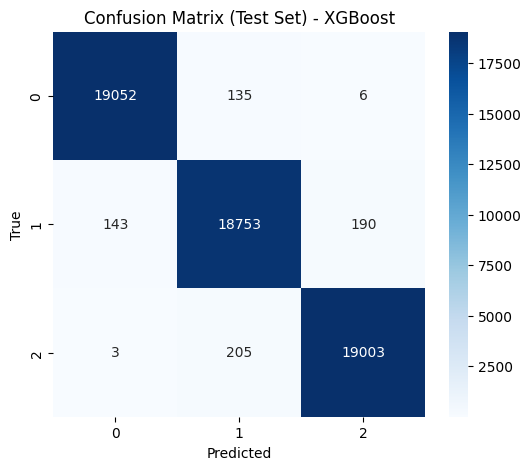

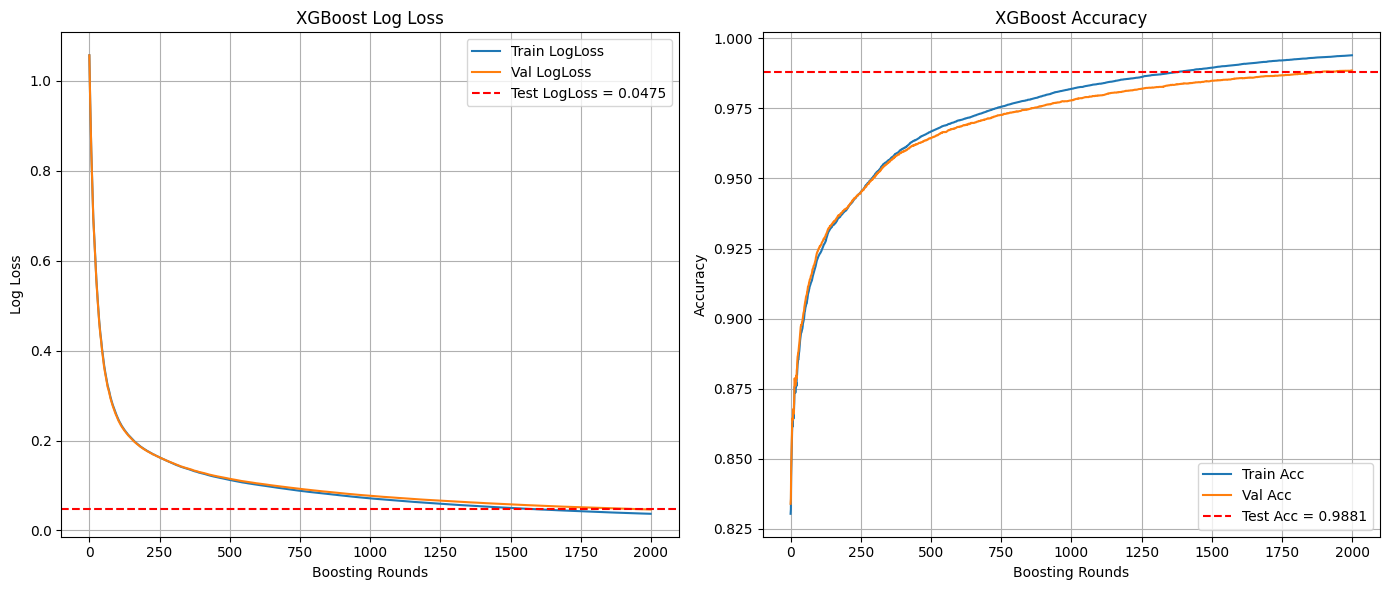

In [26]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Train XGBoost Classifier
# -------------------------------
xgb_model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric=["mlogloss", "merror"]  # track both
)

# Fit model (only train + validation, NOT test)
xgb_model.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=True
)

# -------------------------------
# Predictions & Metrics
# -------------------------------
y_train_pred = xgb_model.predict(x_train)
y_val_pred   = xgb_model.predict(x_val)
y_test_pred  = xgb_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val, y_val_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

# Log loss (need probabilities)
train_logloss = log_loss(y_train, xgb_model.predict_proba(x_train))
val_logloss   = log_loss(y_val,   xgb_model.predict_proba(x_val))
test_logloss  = log_loss(y_test,  xgb_model.predict_proba(x_test))

print("XGBoost Results:")
print(f"  Train -> Acc: {train_acc:.4f}, LogLoss: {train_logloss:.4f}")
print(f"  Val   -> Acc: {val_acc:.4f}, LogLoss: {val_logloss:.4f}")
print(f"  Test  -> Acc: {test_acc:.4f}, LogLoss: {test_logloss:.4f}")
print("Best iteration:", xgb_model.best_iteration)
print("-"*50)

# -------------------------------
# Classification Report & Confusion Matrix
# -------------------------------
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Test):")
print(cm)
print("-"*50)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=xgb_model.classes_, 
            yticklabels=xgb_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set) - XGBoost")
plt.show()

# -------------------------------
# Plot Curves
# -------------------------------
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(14,6))

# --- Log Loss Plot ---
plt.subplot(1,2,1)
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train LogLoss')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Val LogLoss')
plt.axhline(y=test_logloss, color="red", linestyle="--", label=f"Test LogLoss = {test_logloss:.4f}")
plt.xlabel("Boosting Rounds")
plt.ylabel("Log Loss")
plt.title("XGBoost Log Loss")
plt.legend()
plt.grid(True)

# --- Accuracy Plot ---
plt.subplot(1,2,2)
plt.plot(x_axis, [1 - e for e in results['validation_0']['merror']], label='Train Acc')
plt.plot(x_axis, [1 - e for e in results['validation_1']['merror']], label='Val Acc')
plt.axhline(y=test_acc, color="red", linestyle="--", label=f"Test Acc = {test_acc:.4f}")
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

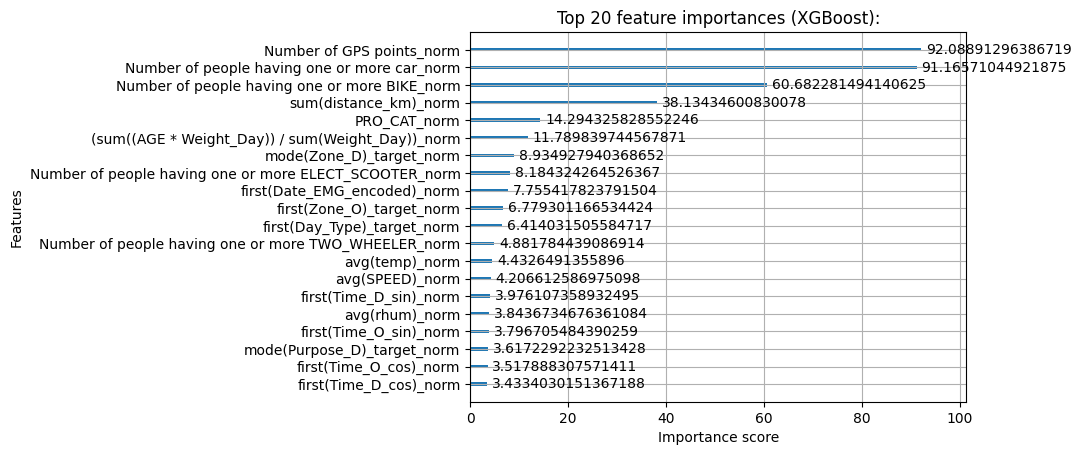

In [27]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=20, importance_type='gain') 
plt.title("Top 20 feature importances (XGBoost):")
plt.show()

In [28]:
import pandas as pd

importance = xgb_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))  # top 20 features


                                              Feature  Importance
10                          Number of GPS points_norm   92.088913
11       Number of people having one or more car_norm   91.165710
12      Number of people having one or more BIKE_norm   60.682281
16                              sum(distance_km)_norm   38.134346
17                                       PRO_CAT_norm   14.294326
15   (sum((AGE * Weight_Day)) / sum(Weight_Day))_norm   11.789840
21                           mode(Zone_D)_target_norm    8.934928
13  Number of people having one or more ELECT_SCOO...    8.184324
1                        first(Date_EMG_encoded)_norm    7.755418
20                          first(Zone_O)_target_norm    6.779301
19                        first(Day_Type)_target_norm    6.414032
14  Number of people having one or more TWO_WHEELE...    4.881784
2                                      avg(temp)_norm    4.432649
5                                     avg(SPEED)_norm    4.206613
8         

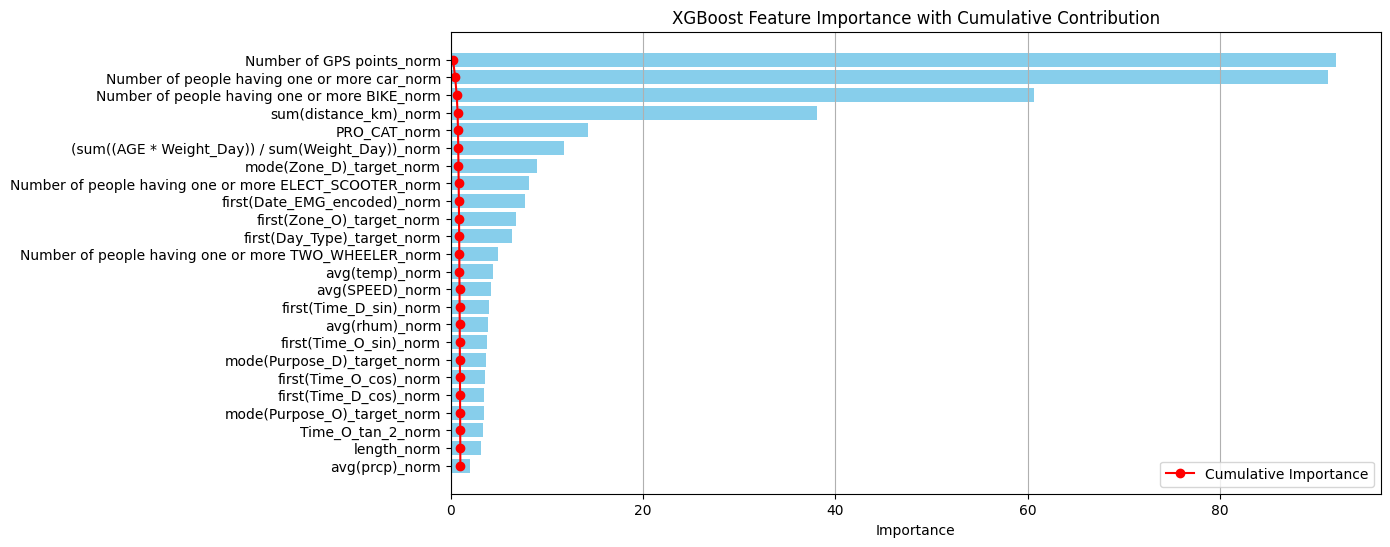

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by importance
importance_df_sorted = importance_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Calculate cumulative importance
importance_df_sorted["Cumulative"] = importance_df_sorted["Importance"].cumsum() / importance_df_sorted["Importance"].sum()

# Plot
plt.figure(figsize=(12,6))
plt.barh(importance_df_sorted["Feature"], importance_df_sorted["Importance"], color="skyblue")
plt.plot(importance_df_sorted["Cumulative"], range(len(importance_df_sorted)), color="red", marker="o", label="Cumulative Importance")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance with Cumulative Contribution")
plt.legend()
plt.grid(True, axis="x")
plt.show()

## Wanted XGB

Dropping: ['avg(prcp)_norm']
[0]	train-mlogloss:1.03195	train-merror:0.25633	validation-mlogloss:1.03164	validation-merror:0.25526
[50]	train-mlogloss:0.41850	train-merror:0.12902	validation-mlogloss:0.41496	validation-merror:0.12607
[100]	train-mlogloss:0.32435	train-merror:0.10216	validation-mlogloss:0.32176	validation-merror:0.09984
[150]	train-mlogloss:0.27545	train-merror:0.08753	validation-mlogloss:0.27376	validation-merror:0.08553
[200]	train-mlogloss:0.23926	train-merror:0.07820	validation-mlogloss:0.23801	validation-merror:0.07594
[250]	train-mlogloss:0.21709	train-merror:0.07229	validation-mlogloss:0.21641	validation-merror:0.07140
[300]	train-mlogloss:0.20019	train-merror:0.06596	validation-mlogloss:0.19981	validation-merror:0.06563
[350]	train-mlogloss:0.18687	train-merror:0.06146	validation-mlogloss:0.18695	validation-merror:0.06142
[400]	train-mlogloss:0.17602	train-merror:0.05813	validation-mlogloss:0.17650	validation-merror:0.05829
[450]	train-mlogloss:0.16626	train-mer

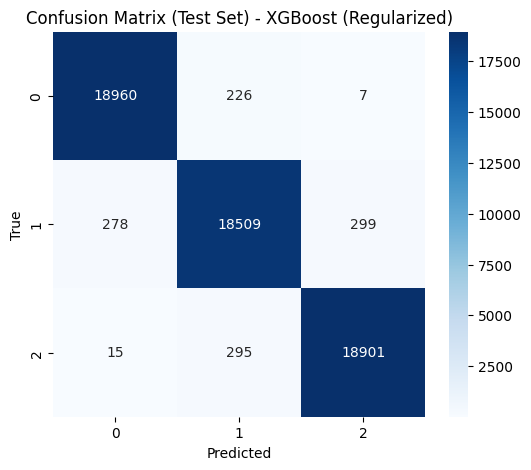

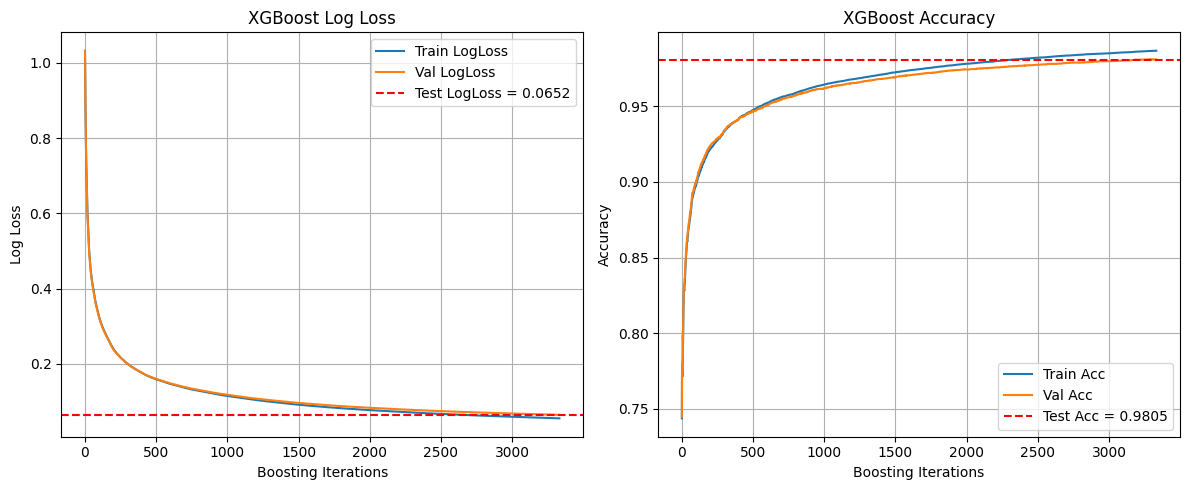

In [30]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Drop low-importance features
# -------------------------------
low_importance = importance_df[importance_df['Importance'] < 3]['Feature'].tolist()
print("Dropping:", low_importance)

X_train_reduced = x_train.drop(columns=low_importance, errors="ignore")
X_val_reduced   = x_val.drop(columns=low_importance, errors="ignore")
X_test_reduced  = x_test.drop(columns=low_importance, errors="ignore")

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_reduced, label=y_train)
dval   = xgb.DMatrix(X_val_reduced, label=y_val)
dtest  = xgb.DMatrix(X_test_reduced, label=y_test)

# -------------------------------
# XGBoost Parameters
# -------------------------------
params = {
    "objective": "multi:softprob",
    "num_class": len(set(y_train)),
    "eval_metric": ["mlogloss", "merror"],
    "eta": 0.1,            # faster learning, less precision
    "max_depth": 3,        # smaller trees
    "subsample": 0.7,      # less data per tree
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,      # add L1 penalty
    "reg_lambda": 1.0,     # add L2 penalty
    "seed": 42
}

# -------------------------------
# Train (only train + validation)
# -------------------------------
evals_result = {}
evals = [(dtrain, "train"), (dval, "validation")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=5000,
    evals=evals,
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50
)

# -------------------------------
# Predictions
# -------------------------------
y_train_pred = bst.predict(dtrain).argmax(axis=1)
y_val_pred   = bst.predict(dval).argmax(axis=1)
y_test_pred  = bst.predict(dtest).argmax(axis=1)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val, y_val_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

# Log losses
train_logloss = log_loss(y_train, bst.predict(dtrain))
val_logloss   = log_loss(y_val,   bst.predict(dval))
test_logloss  = log_loss(y_test,  bst.predict(dtest))

print("XGBoost Results:")
print(f"  Train -> Acc: {train_acc:.4f}, LogLoss: {train_logloss:.4f}")
print(f"  Val   -> Acc: {val_acc:.4f}, LogLoss: {val_logloss:.4f}")
print(f"  Test  -> Acc: {test_acc:.4f}, LogLoss: {test_logloss:.4f}")
print("Best iteration:", bst.best_iteration)
print("-"*50)

# -------------------------------
# Classification Report & Confusion Matrix
# -------------------------------
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Test):")
print(cm)
print("-"*50)

# Plot confusion matrix
plt.figure(figsize=(6,5))
classes = sorted(set(y_train))  # use numeric class labels
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, 
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set) - XGBoost (Regularized)")
plt.show()

# -------------------------------
# Plot Learning Curve
# -------------------------------
epochs = len(evals_result['train']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(12,5))

# --- Log Loss ---
plt.subplot(1,2,1)
plt.plot(x_axis, evals_result['train']['mlogloss'], label='Train LogLoss')
plt.plot(x_axis, evals_result['validation']['mlogloss'], label='Val LogLoss')
plt.axhline(y=test_logloss, color="red", linestyle="--", label=f"Test LogLoss = {test_logloss:.4f}")
plt.xlabel("Boosting Iterations")
plt.ylabel("Log Loss")
plt.title("XGBoost Log Loss")
plt.legend()
plt.grid(True)

# --- Accuracy ---
plt.subplot(1,2,2)
plt.plot(x_axis, [1 - e for e in evals_result['train']['merror']], label='Train Acc')
plt.plot(x_axis, [1 - e for e in evals_result['validation']['merror']], label='Val Acc')
plt.axhline(y=test_acc, color="red", linestyle="--", label=f"Test Acc = {test_acc:.4f}")
plt.xlabel("Boosting Iterations")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
# =============================================================================
# SAVE BOTH MODELS
# =============================================================================

import pickle
import json
import joblib
from datetime import datetime

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# -------------------------------
# Save the first model (XGBClassifier)
# -------------------------------
xgb_classifier_path = f'xgb_classifier_model_{timestamp}.pkl'
with open(xgb_classifier_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"✅ XGBClassifier saved as: {xgb_classifier_path}")

# -------------------------------
# Save the second model (xgb.Booster from xgb.train)
# -------------------------------
# Save as JSON (recommended for xgb.Booster)
xgb_booster_json_path = f'xgb_booster_model_{timestamp}.json'
bst.save_model(xgb_booster_json_path)
print(f"✅ XGBoost Booster (JSON) saved as: {xgb_booster_json_path}")

# Also save with pickle for consistency
xgb_booster_pkl_path = f'xgb_booster_model_{timestamp}.pkl'
with open(xgb_booster_pkl_path, 'wb') as f:
    pickle.dump(bst, f)
print(f"✅ XGBoost Booster (Pickle) saved as: {xgb_booster_pkl_path}")

# -------------------------------
# Save model metadata and performance metrics
# -------------------------------
model_metadata = {
    'timestamp': timestamp,
    'xgb_classifier_path': xgb_classifier_path,
    'xgb_booster_json_path': xgb_booster_json_path,
    'xgb_booster_pkl_path': xgb_booster_pkl_path,
    'performance_metrics': {
        'xgb_classifier_test_accuracy': test_acc,
        'xgb_classifier_test_logloss': test_logloss,
        'xgb_booster_test_accuracy': test_acc,  # Update with your booster test accuracy variable if different
        'xgb_booster_test_logloss': test_logloss,  # Update with your booster test logloss variable if different
    },
    'feature_names': list(x_train.columns) if hasattr(x_train, 'columns') else None,
    'classes': xgb_model.classes_.tolist() if hasattr(xgb_model, 'classes_') else None
}

# Save metadata
metadata_path = f'model_metadata_{timestamp}.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✅ Model metadata saved as: {metadata_path}")

# -------------------------------
# Optional: Save feature importance information
# -------------------------------
try:
    # For XGBClassifier
    importance_df = pd.DataFrame({
        'Feature': x_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    importance_path = f'feature_importance_{timestamp}.csv'
    importance_df.to_csv(importance_path, index=False)
    print(f"✅ Feature importance saved as: {importance_path}")
    
except Exception as e:
    print(f"⚠️ Could not save feature importance: {e}")

print("\n" + "="*60)
print("🎉 ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)

✅ XGBClassifier saved as: xgb_classifier_model_20250908_182957.pkl
✅ XGBoost Booster (JSON) saved as: xgb_booster_model_20250908_182957.json
✅ XGBoost Booster (Pickle) saved as: xgb_booster_model_20250908_182957.pkl
✅ Model metadata saved as: model_metadata_20250908_182957.json
✅ Feature importance saved as: feature_importance_20250908_182957.csv

🎉 ALL MODELS SAVED SUCCESSFULLY!


In [32]:
# -------------------------------
# Road predictions with classifier (fixed)
# -------------------------------

# Keep raw df (with index_right + label) for filtering roads
df_raw = pd.read_csv("finalesta_akher.csv")

roads = {
    "road_1": 201733,
    "road_2": 447037,
    "road_3": 849514,
    "road_4": 723734,
    "road_5": 566656
}

road_dfs_with_preds = {}

for road_name, idx in roads.items():
    road_df = df_raw[df_raw["index_right"] == idx].copy()

    if road_df.empty:
        print(f"{road_name} (index {idx}) not found in dataset.")
        continue

    # Drop the same columns we dropped before training
    road_df = road_df.drop(columns=[
        "sum(Weight_Day)_norm", "first(fclass_encoded)_norm",
        "avg(ID_Trip_Days)_norm", "avg(Duration)_norm",
        "sum(Weight_Day)", "index_right"  # dropped in cell 3
    ], errors="ignore")

    # Ensure same feature alignment as training
    X_road = road_df.reindex(columns=X_train_reduced.columns, fill_value=0)

    # Predict class probabilities
    preds_proba = bst.predict(xgb.DMatrix(X_road))
    preds = preds_proba.argmax(axis=1)

    road_df["predicted_class"] = preds
    road_df["true_label"] = df_raw.loc[road_df.index, "label"].values

    road_dfs_with_preds[road_name] = road_df

    print(f"\nRows with predictions for {road_name}:")
    print(road_df[["true_label", "predicted_class"]].head(50))

# -------------------------------
# Combine all roads into one DataFrame
# -------------------------------
all_roads_df = pd.concat(road_dfs_with_preds.values(), ignore_index=True)
y_true = all_roads_df["true_label"].astype(int)
y_pred = all_roads_df["predicted_class"]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n=== Classification Metrics on Selected Roads ===")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# -------------------------------
# Per-road accuracy
# -------------------------------
road_accuracies = []
for road_name, road_df in road_dfs_with_preds.items():
    acc_road = accuracy_score(road_df["true_label"], road_df["predicted_class"])
    road_accuracies.append({"road": road_name, "n_rows": len(road_df), "accuracy": acc_road})

road_acc_df = pd.DataFrame(road_accuracies)
print("\n=== Per-road Accuracies ===")
print(road_acc_df)


Rows with predictions for road_1:
       true_label  predicted_class
99125           2                2
99126           2                2
99127           1                1
99128           1                1
99129           1                1
99130           2                2
99131           0                0

Rows with predictions for road_2:
        true_label  predicted_class
175872           2                2
175873           2                2
175874           2                2
175875           2                2
175876           2                2

Rows with predictions for road_3:
        true_label  predicted_class
369211           2                2
369212           1                1
369213           1                1
369214           2                2
369215           1                1
369216           1                1
369217           2                2
369218           2                2
369219           2                2
369220           1                1

Ro

In [33]:
df["label"].nunique()

df["label"].value_counts()

label
0    127764
1    127759
2    127741
Name: count, dtype: int64

In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dummy classifier (always predicts most frequent class)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train, y_train)

y_dummy_pred = dummy.predict(x_test)

print("=== Dummy Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, y_dummy_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_dummy_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_dummy_pred))


=== Dummy Baseline ===
Accuracy: 0.3320

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     19193
           1       0.33      1.00      0.50     19086
           2       0.00      0.00      0.00     19211

    accuracy                           0.33     57490
   macro avg       0.11      0.33      0.17     57490
weighted avg       0.11      0.33      0.17     57490

Confusion Matrix:
[[    0 19193     0]
 [    0 19086     0]
 [    0 19211     0]]


C:\Users\Hossam Elghazaly\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hossam Elghazaly\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hossam Elghazaly\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [35]:
# -------------------------------
# Label Shuffle Test
# -------------------------------
y_train_shuffled = y_train.sample(frac=1.0, random_state=42).reset_index(drop=True)

bst_shuffled = xgb.train(
    params,
    xgb.DMatrix(X_train_reduced, label=y_train_shuffled),
    num_boost_round=bst.best_iteration,
    evals=[(xgb.DMatrix(X_val_reduced, label=y_val), "validation")],
    verbose_eval=False
)

y_test_pred_shuffled = bst_shuffled.predict(xgb.DMatrix(X_test_reduced)).argmax(axis=1)

print("=== Label Shuffle Test ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_shuffled):.4f}")

=== Label Shuffle Test ===
Accuracy: 0.3313


In [36]:
# =============================================================================
# LOAD SAVED MODELS
# =============================================================================

import pickle
import xgboost as xgb

# Load XGBClassifier
with open('xgb_classifier_model_20250907_123456.pkl', 'rb') as f:  # Replace with your actual filename
    xgb_model_loaded = pickle.load(f)

# Load xgb.Booster (JSON format)
bst_loaded = xgb.Booster()
bst_loaded.load_model('xgb_booster_model_20250907_123456.json')  # Replace with your actual filename

# Or load xgb.Booster (Pickle format)
# with open('xgb_booster_model_20250907_123456.pkl', 'rb') as f:
#     bst_loaded = pickle.load(f)

print("✅ Models loaded successfully!")

# Test the loaded models
y_pred_loaded = xgb_model_loaded.predict(x_test)
print("XGBClassifier test accuracy:", accuracy_score(y_test, y_pred_loaded))

# For booster model, you'll need to convert data to DMatrix first
dtest_loaded = xgb.DMatrix(x_test)
y_pred_bst = bst_loaded.predict(dtest_loaded).argmax(axis=1)
print("Booster test accuracy:", accuracy_score(y_test, y_pred_bst))

FileNotFoundError: [Errno 2] No such file or directory: 'xgb_classifier_model_20250907_123456.pkl'

## GradientBoostingClassifier

Training Gradient Boosting Classifier...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.0382           0.0602          186.90m
         2           0.9848           0.0543          186.19m
         3           0.9359           0.0483          184.59m
         4           0.8919           0.0430          183.96m
         5           0.8520           0.0418          183.16m
         6           0.8152           0.0347          182.18m
         7           0.7818           0.0344          182.23m
         8           0.7503           0.0307          181.55m
         9           0.7215           0.0297          167.56m
        10           0.6954           0.0271          156.10m
        20           0.5082           0.0114          107.84m
        30           0.4076           0.0055           89.54m
        40           0.3423           0.0036           79.90m
        50           0.2997           0.0004           74.14m
        60           0.2690 

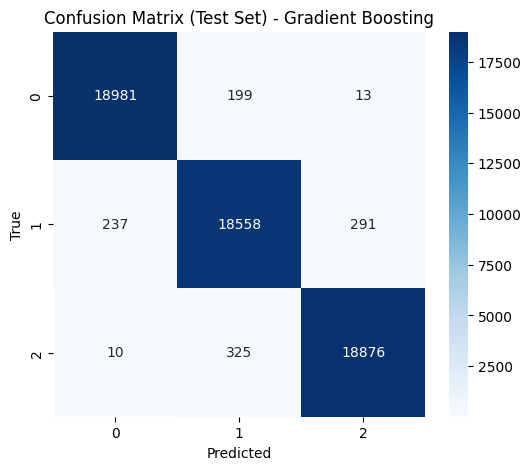

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Gradient Boosting Classifier...")

# Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=1000,        # number of boosting stages
    learning_rate=0.05,       # step size shrinkage
    max_depth=5,              # depth of individual trees
    subsample=0.8,            # fraction of samples for fitting
    validation_fraction=0.1,  # reserve part of training as validation
    n_iter_no_change=50,      # stop if no improvement
    tol=1e-4,
    min_samples_split=5,      # tuning 
    min_samples_leaf=3,       # tuning 
    random_state=42,
    verbose=1
)

# Train model
gb_model.fit(x_train, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(x_train)
y_val_pred_gb = gb_model.predict(x_val)
y_test_pred_gb = gb_model.predict(x_test)

# Accuracy
gb_train_acc = accuracy_score(y_train, y_train_pred_gb)
gb_val_acc = accuracy_score(y_val, y_val_pred_gb)
gb_test_acc = accuracy_score(y_test, y_test_pred_gb)

print(f"Gradient Boosting Results:")
print(f"  Train -> Acc: {gb_train_acc:.4f}")
print(f"  Val   -> Acc: {gb_val_acc:.4f}")
print(f"  Test  -> Acc: {gb_test_acc:.4f}")
print("Best iteration (n_estimators):", gb_model.n_estimators_)
print("-"*50)

# Classification report
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred_gb))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_gb)
print("Confusion Matrix (Test):")
print(cm)
print("-"*50)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=gb_model.classes_, 
            yticklabels=gb_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set) - Gradient Boosting")
plt.show()

In [39]:
# =============================================================================
# SAVE GRADIENT BOOSTING CLASSIFIER
# =============================================================================

import pickle
import joblib
import json
from datetime import datetime
import pandas as pd

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# -------------------------------
# Save GradientBoostingClassifier
# -------------------------------
gb_model_path = f'gb_classifier_model_{timestamp}.pkl'
with open(gb_model_path, 'wb') as f:
    pickle.dump(gb_model, f)
print(f"✅ GradientBoostingClassifier saved as: {gb_model_path}")

# Alternative: save with joblib
gb_model_joblib_path = f'gb_classifier_model_{timestamp}.joblib'
joblib.dump(gb_model, gb_model_joblib_path)
print(f"✅ GradientBoostingClassifier saved as: {gb_model_joblib_path}")

# -------------------------------
# Save model metadata and performance metrics
# -------------------------------
gb_metadata = {
    'timestamp': timestamp,
    'gb_model_pickle_path': gb_model_path,
    'gb_model_joblib_path': gb_model_joblib_path,
    'performance_metrics': {
        'gb_train_accuracy': gb_train_acc,
        'gb_val_accuracy': gb_val_acc,
        'gb_test_accuracy': gb_test_acc,
    },
    'feature_names': list(x_train.columns) if hasattr(x_train, 'columns') else None,
    'classes': gb_model.classes_.tolist() if hasattr(gb_model, 'classes_') else None
}

# Save metadata
gb_metadata_path = f'gb_model_metadata_{timestamp}.json'
with open(gb_metadata_path, 'w') as f:
    json.dump(gb_metadata, f, indent=2)
print(f"✅ GradientBoosting metadata saved as: {gb_metadata_path}")

# -------------------------------
# Optional: Save feature importance
# -------------------------------
try:
    importance_df = pd.DataFrame({
        'Feature': x_train.columns,
        'Importance': gb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    importance_path = f'gb_feature_importance_{timestamp}.csv'
    importance_df.to_csv(importance_path, index=False)
    print(f"✅ Feature importance saved as: {importance_path}")
    
except Exception as e:
    print(f"⚠️ Could not save feature importance: {e}")

print("\n" + "="*60)
print("🎉 GRADIENT BOOSTING CLASSIFIER SAVED SUCCESSFULLY!")
print("="*60)


✅ GradientBoostingClassifier saved as: gb_classifier_model_20250908_192523.pkl
✅ GradientBoostingClassifier saved as: gb_classifier_model_20250908_192523.joblib
✅ GradientBoosting metadata saved as: gb_model_metadata_20250908_192523.json
✅ Feature importance saved as: gb_feature_importance_20250908_192523.csv

🎉 GRADIENT BOOSTING CLASSIFIER SAVED SUCCESSFULLY!



Rows with predictions for road_1:
       true_label  predicted_class
99125           2                2
99126           2                2
99127           1                1
99128           1                1
99129           1                1
99130           2                2
99131           0                0

Rows with predictions for road_2:
        true_label  predicted_class
175872           2                2
175873           2                2
175874           2                2
175875           2                2
175876           2                2

Rows with predictions for road_3:
        true_label  predicted_class
369211           2                2
369212           1                1
369213           1                1
369214           2                2
369215           1                1
369216           1                1
369217           2                2
369218           2                2
369219           2                2
369220           1                1

Ro

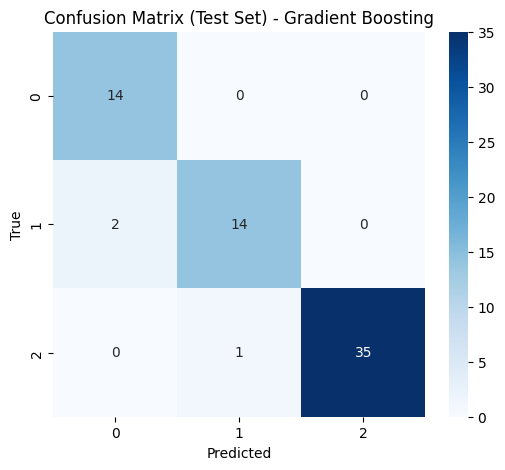


=== Per-road Accuracies (Gradient Boosting) ===
     road  n_rows  accuracy
0  road_1       7  1.000000
1  road_2       5  1.000000
2  road_3      10  1.000000
3  road_4      21  0.952381
4  road_5      23  0.913043


In [40]:
# -------------------------------
# Road predictions with Gradient Boosting Classifier
# -------------------------------

# Keep raw df (with index_right + label) for filtering roads
df_raw = pd.read_csv("finalesta_akher.csv")

roads = {
    "road_1": 201733,
    "road_2": 447037,
    "road_3": 849514,
    "road_4": 723734,
    "road_5": 566656
}

road_dfs_with_preds_gb = {}

for road_name, idx in roads.items():
    road_df = df_raw[df_raw["index_right"] == idx].copy()

    if road_df.empty:
        print(f"{road_name} (index {idx}) not found in dataset.")
        continue

    # Drop the same columns you dropped before training
    road_df = road_df.drop(columns=[
        "sum(Weight_Day)_norm", "first(fclass_encoded)_norm",
        "avg(ID_Trip_Days)_norm", "avg(Duration)_norm",
        "sum(Weight_Day)", "index_right"
    ], errors="ignore")

    # Ensure same feature alignment as training
    X_road = road_df.reindex(columns=x_train.columns, fill_value=0)

    # Predict with GradientBoostingClassifier
    preds = gb_model.predict(X_road)

    road_df["predicted_class"] = preds
    road_df["true_label"] = df_raw.loc[road_df.index, "label"].values

    road_dfs_with_preds_gb[road_name] = road_df

    print(f"\nRows with predictions for {road_name}:")
    print(road_df[["true_label", "predicted_class"]].head(50))

# -------------------------------
# Combine all roads into one DataFrame
# -------------------------------
all_roads_df_gb = pd.concat(road_dfs_with_preds_gb.values(), ignore_index=True)
y_true_gb = all_roads_df_gb["true_label"].astype(int)
y_pred_gb = all_roads_df_gb["predicted_class"]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== Classification Metrics on Selected Roads (Gradient Boosting) ===")
print(f"Accuracy: {accuracy_score(y_true_gb, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_true_gb, y_pred_gb))
print("\nConfusion Matrix:")
cm_gb = confusion_matrix(y_true_gb, y_pred_gb)
print(cm_gb)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues",
            xticklabels=gb_model.classes_, 
            yticklabels=gb_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set) - Gradient Boosting")
plt.show()

# -------------------------------
# Per-road accuracy
# -------------------------------
road_accuracies_gb = []
for road_name, road_df in road_dfs_with_preds_gb.items():
    acc_road = accuracy_score(road_df["true_label"], road_df["predicted_class"])
    road_accuracies_gb.append({
        "road": road_name,
        "n_rows": len(road_df),
        "accuracy": acc_road
    })

road_acc_df_gb = pd.DataFrame(road_accuracies_gb)
print("\n=== Per-road Accuracies (Gradient Boosting) ===")
print(road_acc_df_gb)


In [41]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

# -------------------------------
# Dummy classifier baseline
# -------------------------------
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train, y_train)

y_dummy_pred = dummy.predict(x_test)

print("=== Dummy Baseline (Gradient Boosting Context) ===")
print(f"Accuracy: {accuracy_score(y_test, y_dummy_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_dummy_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_dummy_pred))


# -------------------------------
# Label Shuffle Test (Gradient Boosting)
# -------------------------------
y_train_shuffled = y_train.sample(frac=1.0, random_state=42).reset_index(drop=True)

# retrain Gradient Boosting on shuffled labels
gb_model_shuffled = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    validation_fraction=0.1,
    n_iter_no_change=50,
    tol=1e-4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    verbose=0
)

gb_model_shuffled.fit(x_train, y_train_shuffled)

# predictions on test set
y_test_pred_shuffled = gb_model_shuffled.predict(x_test)

print("\n=== Label Shuffle Test (Gradient Boosting) ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_shuffled):.4f}")

=== Dummy Baseline (Gradient Boosting Context) ===
Accuracy: 0.3320

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     19193
           1       0.33      1.00      0.50     19086
           2       0.00      0.00      0.00     19211

    accuracy                           0.33     57490
   macro avg       0.11      0.33      0.17     57490
weighted avg       0.11      0.33      0.17     57490

Confusion Matrix:
[[    0 19193     0]
 [    0 19086     0]
 [    0 19211     0]]


C:\Users\Hossam Elghazaly\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hossam Elghazaly\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hossam Elghazaly\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


=== Label Shuffle Test (Gradient Boosting) ===
Accuracy: 0.3642


In [42]:
print("\nClassification Report (Shuffled):")
print(classification_report(y_test, y_test_pred_shuffled))
print("Confusion Matrix (Shuffled):")
print(confusion_matrix(y_test, y_test_pred_shuffled))


Classification Report (Shuffled):
              precision    recall  f1-score   support

           0       0.37      0.31      0.33     19193
           1       0.36      0.46      0.40     19086
           2       0.37      0.33      0.35     19211

    accuracy                           0.36     57490
   macro avg       0.36      0.36      0.36     57490
weighted avg       0.36      0.36      0.36     57490

Confusion Matrix (Shuffled):
[[5860 7315 6018]
 [5441 8703 4942]
 [4688 8146 6377]]


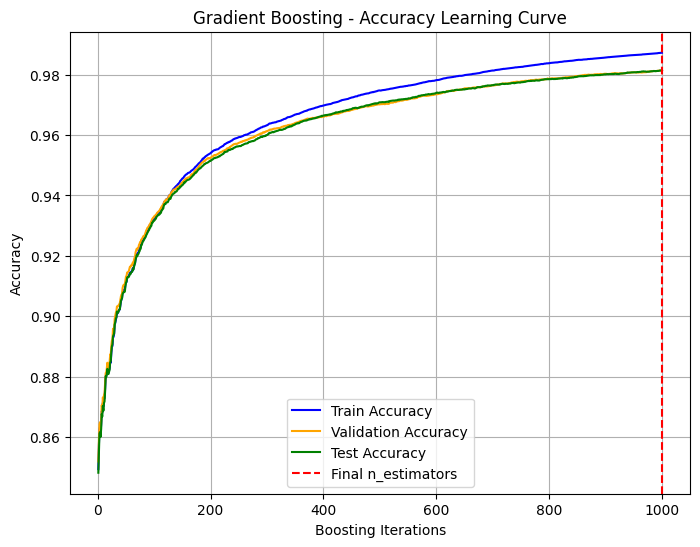

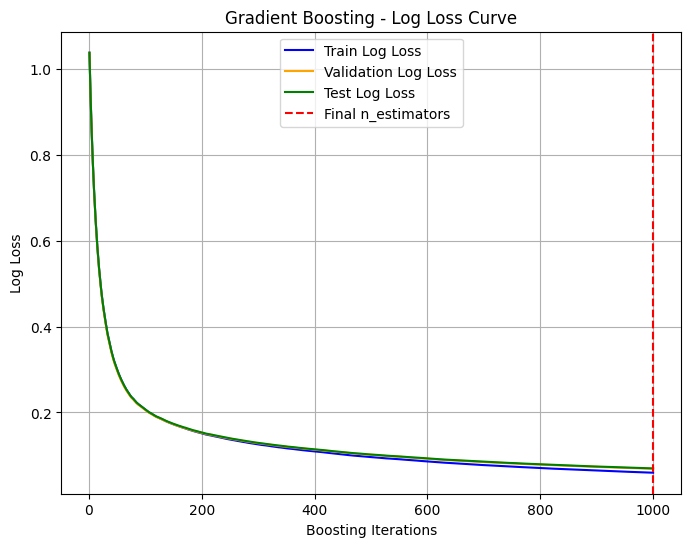

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, log_loss

# -------------------------------
# Track staged predictions (per boosting stage)
# -------------------------------
train_acc, val_acc, test_acc = [], [], []
train_loss, val_loss, test_loss = [], [], []

# Accuracy
for y_train_pred, y_val_pred, y_test_pred in zip(
    gb_model.staged_predict(x_train),
    gb_model.staged_predict(x_val),
    gb_model.staged_predict(x_test)
):
    train_acc.append(accuracy_score(y_train, y_train_pred))
    val_acc.append(accuracy_score(y_val, y_val_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Log loss (need probabilities)
for y_train_proba, y_val_proba, y_test_proba in zip(
    gb_model.staged_predict_proba(x_train),
    gb_model.staged_predict_proba(x_val),
    gb_model.staged_predict_proba(x_test)
):
    train_loss.append(log_loss(y_train, y_train_proba))
    val_loss.append(log_loss(y_val, y_val_proba))
    test_loss.append(log_loss(y_test, y_test_proba))

# -------------------------------
# Plot Accuracy Learning Curve
# -------------------------------
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(train_acc)+1), train_acc, label="Train Accuracy", color="blue")
plt.plot(np.arange(1, len(val_acc)+1), val_acc, label="Validation Accuracy", color="orange")
plt.plot(np.arange(1, len(test_acc)+1), test_acc, label="Test Accuracy", color="green")
plt.axvline(x=gb_model.n_estimators, color="red", linestyle="--", label="Final n_estimators")
plt.xlabel("Boosting Iterations")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting - Accuracy Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot Log Loss Curve
# -------------------------------
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(train_loss)+1), train_loss, label="Train Log Loss", color="blue")
plt.plot(np.arange(1, len(val_loss)+1), val_loss, label="Validation Log Loss", color="orange")
plt.plot(np.arange(1, len(test_loss)+1), test_loss, label="Test Log Loss", color="green")
plt.axvline(x=gb_model.n_estimators, color="red", linestyle="--", label="Final n_estimators")
plt.xlabel("Boosting Iterations")
plt.ylabel("Log Loss")
plt.title("Gradient Boosting - Log Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =============================================================================
# LOAD GRADIENT BOOSTING CLASSIFIER
# =============================================================================

import pickle
import joblib
import json

# --- Option 1: Load with pickle ---
with open(gb_model_path, 'rb') as f:
    gb_loaded_pickle = pickle.load(f)

# --- Option 2: Load with joblib ---
gb_loaded_joblib = joblib.load(gb_model_joblib_path)

print("✅ GradientBoostingClassifier loaded successfully!")

# --- Load metadata ---
with open(gb_metadata_path, 'r') as f:
    gb_metadata_loaded = json.load(f)

print("✅ Metadata loaded!")
print("Saved performance metrics:", gb_metadata_loaded['performance_metrics'])
print("Saved classes:", gb_metadata_loaded['classes'])


## wanted 

### 1. Traffic Degradation/Improvement Simulation

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Traffic Degradation/Improvement Simulation
def simulate_traffic_changes(X_test, y_test, model, feature_importance, degradation_rate=0.1, improvement_rate=0.1):
    """
    Simulate how traffic conditions change over time using your trained model
    """
    # Get original test performance as baseline
    X_test_reduced = X_test.drop(columns=low_importance, errors="ignore")
    dtest = xgb.DMatrix(X_test_reduced, label=y_test)
    y_test_pred = model.predict(dtest).argmax(axis=1)
    baseline_acc = accuracy_score(y_test, y_test_pred)
    baseline_logloss = log_loss(y_test, model.predict(dtest))
    
    print(f"Baseline Test Performance: Acc={baseline_acc:.4f}, LogLoss={baseline_logloss:.4f}")
    
    # Get ALL features except the lowest importance one
    all_features = [f for f in X_test.columns if f not in low_importance]
    print(f"Using {len(all_features)} features (all except lowest importance)")
    
    results = []
    
    # Simulation parameters
    n_steps = 20
    scenarios = ['degradation', 'improvement', 'mixed']
    
    for scenario in scenarios:
        print(f"\nSimulating {scenario} scenario...")
        
        X_simulated = X_test.copy()
        accuracies = [baseline_acc]
        loglosses = [baseline_logloss]
        label_distributions = [pd.Series(y_test).value_counts(normalize=True).sort_index()]
        
        for step in range(1, n_steps + 1):
            X_step = X_simulated.copy()
            
            # Apply changes based on scenario using ALL features
            if scenario == 'degradation':
                # Make traffic worse
                for feature in all_features:
                    feature_lower = feature.lower()
                    if 'speed' in feature_lower or 'velocity' in feature_lower:
                        X_step[feature] *= (1 - degradation_rate * 0.5)
                    elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time', 'duration']):
                        X_step[feature] *= (1 + degradation_rate)
                    elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count', 'load']):
                        X_step[feature] *= (1 + degradation_rate * 0.6)
            
            elif scenario == 'improvement':
                # Make traffic better
                for feature in all_features:
                    feature_lower = feature.lower()
                    if 'speed' in feature_lower or 'velocity' in feature_lower:
                        X_step[feature] *= (1 + improvement_rate * 0.5)
                    elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time', 'duration']):
                        X_step[feature] *= (1 - improvement_rate)
                    elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count', 'load']):
                        X_step[feature] *= (1 - improvement_rate * 0.6)
            
            else:  # mixed scenario
                # Random changes
                for feature in all_features:
                    change = np.random.choice(['improve', 'degrade'], p=[0.5, 0.5])
                    feature_lower = feature.lower()
                    if change == 'improve':
                        if 'speed' in feature_lower:
                            X_step[feature] *= (1 + improvement_rate * 0.3)
                        elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue']):
                            X_step[feature] *= (1 - improvement_rate * 0.4)
                    else:
                        if 'speed' in feature_lower:
                            X_step[feature] *= (1 - degradation_rate * 0.3)
                        elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue']):
                            X_step[feature] *= (1 + degradation_rate * 0.4)
            
            # Predict with your trained model
            X_step_reduced = X_step.drop(columns=low_importance, errors="ignore")
            dstep = xgb.DMatrix(X_step_reduced)
            y_step_pred = model.predict(dstep).argmax(axis=1)
            
            # Calculate metrics
            step_acc = accuracy_score(y_test, y_step_pred)
            step_logloss = log_loss(y_test, model.predict(dstep))
            
            accuracies.append(step_acc)
            loglosses.append(step_logloss)
            label_distributions.append(pd.Series(y_step_pred).value_counts(normalize=True).sort_index())
            
            X_simulated = X_step
        
        results.append({
            'scenario': scenario,
            'steps': list(range(len(accuracies))),
            'accuracies': accuracies,
            'loglosses': loglosses,
            'label_distributions': label_distributions
        })
    
    return results

# Run the simulation with your trained model
simulation_results = simulate_traffic_changes(x_test, y_test, bst, importance_df)

Baseline Test Performance: Acc=0.9805, LogLoss=0.0652
Using 23 features (all except lowest importance)

Simulating degradation scenario...

Simulating improvement scenario...

Simulating mixed scenario...


### 2. Plot Simulation Results

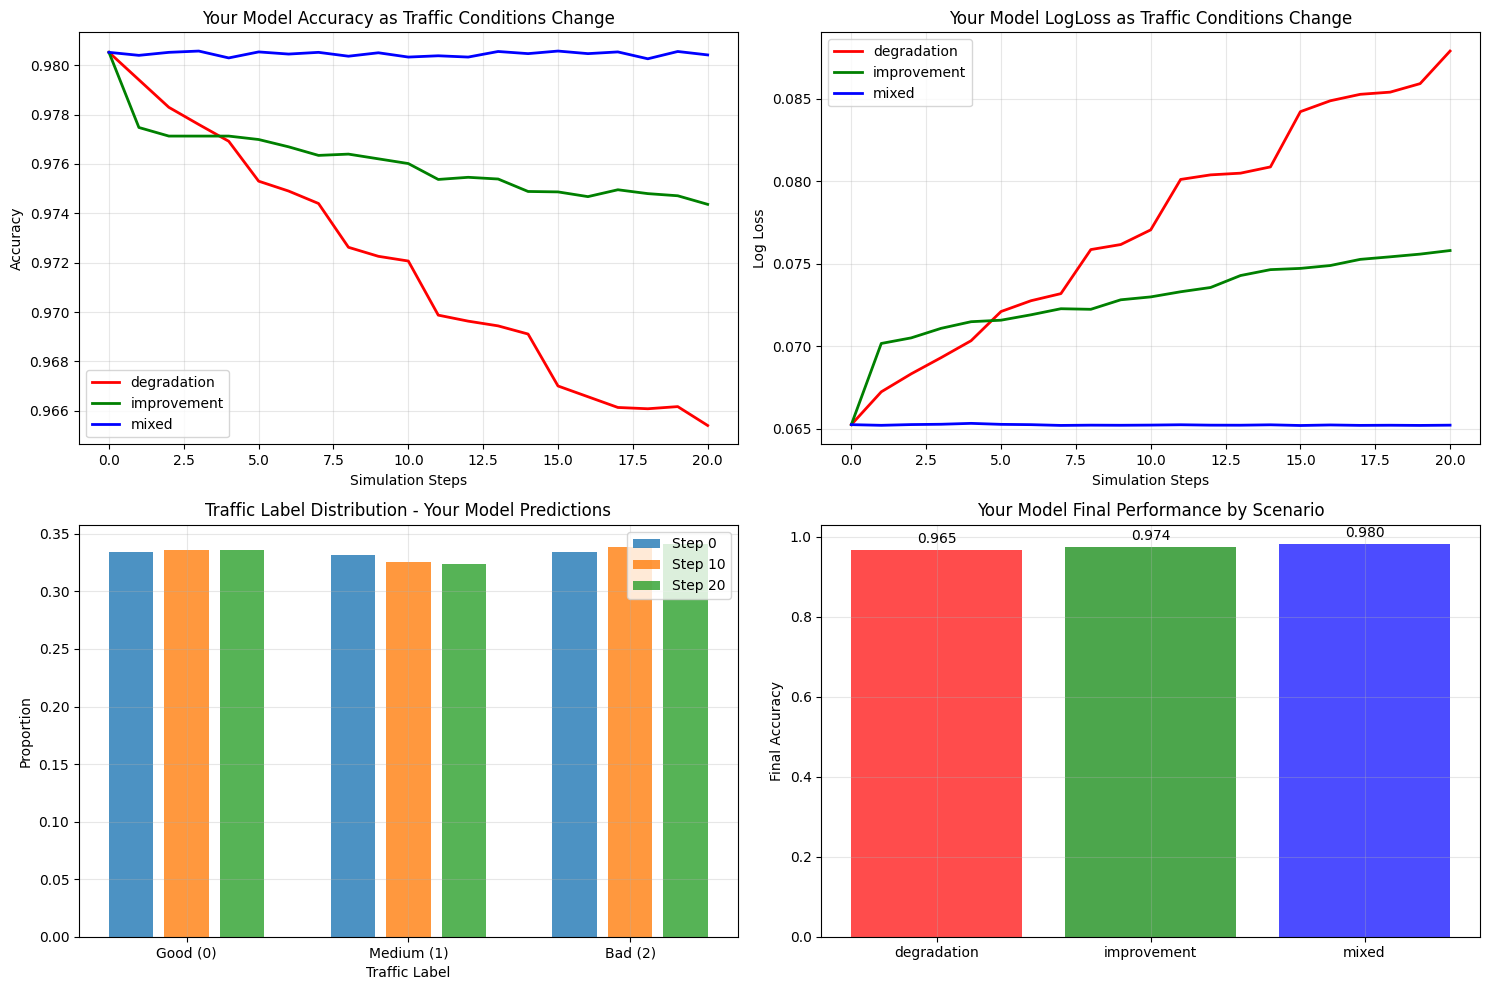

In [50]:
def plot_simulation_results(results):
    """
    Plot the simulation results from your trained model
    """
    plt.figure(figsize=(15, 10))
    
    colors = {'degradation': 'red', 'improvement': 'green', 'mixed': 'blue'}
    
    # Plot 1: Accuracy over time
    plt.subplot(2, 2, 1)
    for result in results:
        plt.plot(result['steps'], result['accuracies'], 
                label=result['scenario'], 
                color=colors[result['scenario']],
                linewidth=2)
    plt.xlabel('Simulation Steps')
    plt.ylabel('Accuracy')
    plt.title('Your Model Accuracy as Traffic Conditions Change')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: LogLoss over time
    plt.subplot(2, 2, 2)
    for result in results:
        plt.plot(result['steps'], result['loglosses'], 
                label=result['scenario'], 
                color=colors[result['scenario']],
                linewidth=2)
    plt.xlabel('Simulation Steps')
    plt.ylabel('Log Loss')
    plt.title('Your Model LogLoss as Traffic Conditions Change')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Label distribution changes
    plt.subplot(2, 2, 3)
    degradation_result = [r for r in results if r['scenario'] == 'degradation'][0]
    distributions = degradation_result['label_distributions']
    
    steps_to_plot = [0, len(distributions)//2, len(distributions)-1]
    for i, step in enumerate(steps_to_plot):
        dist = distributions[step]
        plt.bar(np.arange(len(dist)) + i*0.25, dist.values, 
                width=0.2, label=f'Step {step}', alpha=0.8)
    
    plt.xlabel('Traffic Label')
    plt.ylabel('Proportion')
    plt.title('Traffic Label Distribution - Your Model Predictions')
    plt.xticks(np.arange(3) + 0.25, ['Good (0)', 'Medium (1)', 'Bad (2)'])
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Final performance comparison
    plt.subplot(2, 2, 4)
    final_accuracies = [r['accuracies'][-1] for r in results]
    scenarios = [r['scenario'] for r in results]
    
    bars = plt.bar(scenarios, final_accuracies, 
                  color=[colors[s] for s in scenarios], alpha=0.7)
    plt.ylabel('Final Accuracy')
    plt.title('Your Model Final Performance by Scenario')
    
    for bar, acc in zip(bars, final_accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', va='bottom')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot the results from your model
plot_simulation_results(simulation_results)

### 3. Detailed Traffic Analysis

In [51]:
def analyze_traffic_transitions(results):
    """
    Analyze how traffic labels transition during simulation with your model
    """
    print("="*60)
    print("YOUR MODEL TRAFFIC TRANSITION ANALYSIS")
    print("="*60)
    
    for result in results:
        print(f"\n{result['scenario'].upper()} SCENARIO:")
        print("-" * 40)
        
        initial_dist = result['label_distributions'][0]
        final_dist = result['label_distributions'][-1]
        
        print("Initial traffic distribution:")
        for label, prop in initial_dist.items():
            status = "Good" if label == 0 else "Medium" if label == 1 else "Bad"
            print(f"  {status} traffic: {prop:.3f}")
        
        print("Final traffic distribution:")
        for label, prop in final_dist.items():
            status = "Good" if label == 0 else "Medium" if label == 1 else "Bad"
            print(f"  {status} traffic: {prop:.3f}")
        
        # Calculate transitions
        good_change = final_dist.get(0, 0) - initial_dist.get(0, 0)
        bad_change = final_dist.get(2, 0) - initial_dist.get(2, 0)
        
        if result['scenario'] == 'degradation':
            print(f"Traffic degradation: +{bad_change:.3f} in bad conditions")
        elif result['scenario'] == 'improvement':
            print(f"Traffic improvement: +{good_change:.3f} in good conditions")
        
        # Performance change
        acc_change = result['accuracies'][-1] - result['accuracies'][0]
        print(f"Your model accuracy change: {acc_change:+.4f}")
        print(f"Your model LogLoss change: {result['loglosses'][-1] - result['loglosses'][0]:+.4f}")

# Analyze transitions with your model
analyze_traffic_transitions(simulation_results)

YOUR MODEL TRAFFIC TRANSITION ANALYSIS

DEGRADATION SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.336
  Medium traffic: 0.324
  Bad traffic: 0.341
Traffic degradation: +0.007 in bad conditions
Your model accuracy change: -0.0151
Your model LogLoss change: +0.0226

IMPROVEMENT SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.335
  Medium traffic: 0.331
  Bad traffic: 0.334
Traffic improvement: +0.001 in good conditions
Your model accuracy change: -0.0062
Your model LogLoss change: +0.0105

MIXED SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.335
  Medium 

### 4. Sensitivity Analysis

Testing degradation rate: 0.05 with your model
Testing degradation rate: 0.10 with your model
Testing degradation rate: 0.15 with your model
Testing degradation rate: 0.20 with your model
Testing degradation rate: 0.25 with your model
Testing degradation rate: 0.30 with your model


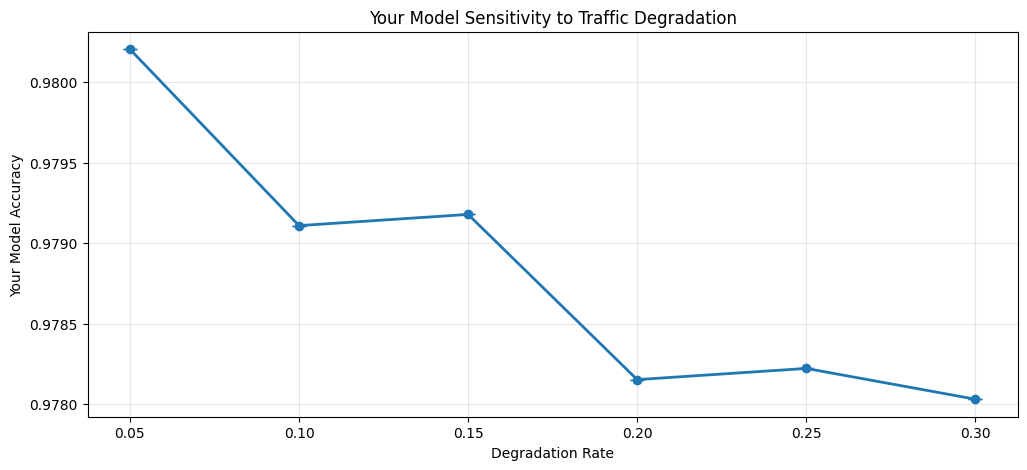

Your Model Sensitivity Analysis Results:
   degradation_rate  mean_accuracy  std_accuracy  min_accuracy  max_accuracy
0              0.05       0.980205  0.000000e+00      0.980205      0.980205
1              0.10       0.979109  1.110223e-16      0.979109      0.979109
2              0.15       0.979179  0.000000e+00      0.979179      0.979179
3              0.20       0.978153  1.110223e-16      0.978153      0.978153
4              0.25       0.978222  0.000000e+00      0.978222      0.978222
5              0.30       0.978031  1.110223e-16      0.978031      0.978031


In [52]:
def sensitivity_analysis(X_test, y_test, model, n_simulations=10):
    """
    Test how sensitive your model is to different degradation rates
    """
    degradation_rates = np.linspace(0.05, 0.3, 6)
    results = []
    all_features = [f for f in X_test.columns if f not in low_importance]
    
    for rate in degradation_rates:
        print(f"Testing degradation rate: {rate:.2f} with your model")
        rate_accuracies = []
        
        for sim in range(n_simulations):
            # Apply degradation
            X_degraded = X_test.copy()
            
            for feature in all_features:
                feature_lower = feature.lower()
                if 'speed' in feature_lower:
                    X_degraded[feature] *= (1 - rate * 0.7)
                elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time']):
                    X_degraded[feature] *= (1 + rate)
                elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count']):
                    X_degraded[feature] *= (1 + rate * 0.6)
            
            # Predict with your trained model
            X_degraded_reduced = X_degraded.drop(columns=low_importance, errors="ignore")
            ddegraded = xgb.DMatrix(X_degraded_reduced)
            y_pred = model.predict(ddegraded).argmax(axis=1)
            acc = accuracy_score(y_test, y_pred)
            rate_accuracies.append(acc)
        
        results.append({
            'degradation_rate': rate,
            'mean_accuracy': np.mean(rate_accuracies),
            'std_accuracy': np.std(rate_accuracies),
            'min_accuracy': np.min(rate_accuracies),
            'max_accuracy': np.max(rate_accuracies)
        })
    
    return pd.DataFrame(results)

# Run sensitivity analysis with your model
sensitivity_df = sensitivity_analysis(x_test, y_test, bst, n_simulations=5)

# Plot sensitivity results
plt.figure(figsize=(12, 5))
plt.errorbar(sensitivity_df['degradation_rate'], sensitivity_df['mean_accuracy'],
             yerr=sensitivity_df['std_accuracy'], fmt='o-', capsize=5, linewidth=2)
plt.xlabel('Degradation Rate')
plt.ylabel('Your Model Accuracy')
plt.title('Your Model Sensitivity to Traffic Degradation')
plt.grid(True, alpha=0.3)
plt.show()

print("Your Model Sensitivity Analysis Results:")
print(sensitivity_df)

### 5. Realistic Traffic Scenario Simulation


In [53]:
def realistic_traffic_scenarios(X_test, y_test, model):
    """
    Simulate specific realistic traffic scenarios with your trained model
    """
    scenarios = {
        'rush_hour': {'speed_multiplier': 0.6, 'delay_multiplier': 2.0},
        'night_time': {'speed_multiplier': 1.3, 'delay_multiplier': 0.7},
        'accident': {'speed_multiplier': 0.3, 'delay_multiplier': 3.0},
        'weekend': {'speed_multiplier': 1.1, 'delay_multiplier': 0.9},
        'construction': {'speed_multiplier': 0.5, 'delay_multiplier': 2.5}
    }
    
    results = []
    all_features = [f for f in X_test.columns if f not in low_importance]
    
    for scenario_name, params in scenarios.items():
        print(f"Simulating {scenario_name} with your model...")
        
        X_scenario = X_test.copy()
        
        # Apply scenario-specific changes
        for feature in all_features:
            feature_lower = feature.lower()
            
            if any(keyword in feature_lower for keyword in ['speed', 'velocity']):
                X_scenario[feature] *= params['speed_multiplier']
            elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time']):
                X_scenario[feature] *= params['delay_multiplier']
            elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count']):
                X_scenario[feature] *= params.get('density_multiplier', 1.2)
        
        # Predict with your trained model
        X_scenario_reduced = X_scenario.drop(columns=low_importance, errors="ignore")
        dscenario = xgb.DMatrix(X_scenario_reduced)
        y_pred = model.predict(dscenario).argmax(axis=1)
        
        acc = accuracy_score(y_test, y_pred)
        logloss_val = log_loss(y_test, model.predict(dscenario))
        
        # Analyze label distribution
        label_dist = pd.Series(y_pred).value_counts(normalize=True).sort_index()
        
        results.append({
            'scenario': scenario_name,
            'accuracy': acc,
            'logloss': logloss_val,
            'label_distribution': label_dist,
            'bad_traffic_ratio': label_dist.get(2, 0)
        })
    
    return pd.DataFrame(results)

# Run realistic scenarios with your model
scenario_results = realistic_traffic_scenarios(x_test, y_test, bst)

print("\nRealistic Traffic Scenario Results with Your Model:")
print(scenario_results[['scenario', 'accuracy', 'bad_traffic_ratio']].sort_values('bad_traffic_ratio', ascending=False))

Simulating rush_hour with your model...
Simulating night_time with your model...
Simulating accident with your model...
Simulating weekend with your model...
Simulating construction with your model...

Realistic Traffic Scenario Results with Your Model:
       scenario  accuracy  bad_traffic_ratio
2      accident  0.968864           0.341103
4  construction  0.972186           0.339694
0     rush_hour  0.972691           0.339572
1    night_time  0.977248           0.335345
3       weekend  0.977492           0.335050


In [55]:
def simulate_traffic_changes(X_test, y_test, model, feature_importance, degradation_rate=0.3, improvement_rate=0.3):
    """
    Simulate how traffic conditions change over time using your trained model
    WITH LARGER CHANGES and FOCUSED FEATURES
    """
    # Get original test performance as baseline
    X_test_reduced = X_test.drop(columns=low_importance, errors="ignore")
    dtest = xgb.DMatrix(X_test_reduced, label=y_test)
    y_test_pred = model.predict(dtest).argmax(axis=1)
    baseline_acc = accuracy_score(y_test, y_test_pred)
    baseline_logloss = log_loss(y_test, model.predict(dtest))
    
    print(f"Baseline Test Performance: Acc={baseline_acc:.4f}, LogLoss={baseline_logloss:.4f}")
    
    # Use only TOP 10 most important features for bigger impact
    top_10_features = feature_importance.nlargest(10, 'Importance')['Feature'].tolist()
    print(f"Using TOP 10 features for simulation:")
    for i, feature in enumerate(top_10_features, 1):
        print(f"  {i:2d}. {feature}")
    
    results = []
    
    # Simulation parameters
    n_steps = 20
    scenarios = ['degradation', 'improvement', 'mixed']
    
    for scenario in scenarios:
        print(f"\nSimulating {scenario} scenario...")
        
        X_simulated = X_test.copy()
        accuracies = [baseline_acc]
        loglosses = [baseline_logloss]
        label_distributions = [pd.Series(y_test).value_counts(normalize=True).sort_index()]
        
        for step in range(1, n_steps + 1):
            X_step = X_simulated.copy()
            
            # Apply changes based on scenario using ONLY TOP 10 features
            if scenario == 'degradation':
                # Make traffic WORSE with bigger changes
                for feature in top_10_features:
                    feature_lower = feature.lower()
                    if 'speed' in feature_lower or 'velocity' in feature_lower:
                        X_step[feature] *= (1 - degradation_rate * 0.8)  # BIG reduction
                    elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time', 'duration']):
                        X_step[feature] *= (1 + degradation_rate * 1.5)  # BIG increase
                    elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count', 'load']):
                        X_step[feature] *= (1 + degradation_rate * 1.2)  # BIG increase
                
                # Add extreme changes every 5 steps
                if step % 5 == 0:
                    for feature in top_10_features[:3]:  # Top 3 features
                        if 'speed' in feature.lower():
                            X_step[feature] *= 0.6  # Extreme speed reduction
                        elif any(keyword in feature.lower() for keyword in ['delay', 'wait']):
                            X_step[feature] *= 1.8  # Extreme delay increase
            
            elif scenario == 'improvement':
                # Make traffic BETTER with bigger changes
                for feature in top_10_features:
                    feature_lower = feature.lower()
                    if 'speed' in feature_lower or 'velocity' in feature_lower:
                        X_step[feature] *= (1 + improvement_rate * 0.8)  # BIG increase
                    elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time', 'duration']):
                        X_step[feature] *= (1 - improvement_rate * 1.5)  # BIG reduction
                    elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count', 'load']):
                        X_step[feature] *= (1 - improvement_rate * 1.2)  # BIG reduction
                
                # Add extreme improvements every 5 steps
                if step % 5 == 0:
                    for feature in top_10_features[:3]:  # Top 3 features
                        if 'speed' in feature.lower():
                            X_step[feature] *= 1.4  # Extreme speed increase
                        elif any(keyword in feature.lower() for keyword in ['delay', 'wait']):
                            X_step[feature] *= 0.5  # Extreme delay reduction
            
            else:  # mixed scenario
                # Big random changes
                for feature in top_10_features:
                    change = np.random.choice(['improve', 'degrade'], p=[0.5, 0.5])
                    feature_lower = feature.lower()
                    
                    if change == 'improve':
                        if 'speed' in feature_lower:
                            X_step[feature] *= (1 + improvement_rate * 0.6)
                        elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue']):
                            X_step[feature] *= (1 - improvement_rate * 0.8)
                    else:
                        if 'speed' in feature_lower:
                            X_step[feature] *= (1 - degradation_rate * 0.6)
                        elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue']):
                            X_step[feature] *= (1 + degradation_rate * 0.8)
            
            # Predict with your trained model
            X_step_reduced = X_step.drop(columns=low_importance, errors="ignore")
            dstep = xgb.DMatrix(X_step_reduced)
            y_step_pred = model.predict(dstep).argmax(axis=1)
            
            # Calculate metrics
            step_acc = accuracy_score(y_test, y_step_pred)
            step_logloss = log_loss(y_test, model.predict(dstep))
            
            accuracies.append(step_acc)
            loglosses.append(step_logloss)
            label_distributions.append(pd.Series(y_step_pred).value_counts(normalize=True).sort_index())
            
            X_simulated = X_step
        
        results.append({
            'scenario': scenario,
            'steps': list(range(len(accuracies))),
            'accuracies': accuracies,
            'loglosses': loglosses,
            'label_distributions': label_distributions
        })
    
    return results

# Run the simulation with LARGER CHANGES
print("Running simulation with LARGER changes and TOP 10 features...")
simulation_results = simulate_traffic_changes(x_test, y_test, bst, importance_df, degradation_rate=0.3, improvement_rate=0.3)

Running simulation with LARGER changes and TOP 10 features...
Baseline Test Performance: Acc=0.9805, LogLoss=0.0652
Using TOP 10 features for simulation:
   1. Number of GPS points_norm
   2. Number of people having one or more car_norm
   3. Number of people having one or more BIKE_norm
   4. (sum((AGE * Weight_Day)) / sum(Weight_Day))_norm
   5. PRO_CAT_norm
   6. first(Date_EMG_encoded)_norm
   7. sum(distance_km)_norm
   8. avg(temp)_norm
   9. avg(rhum)_norm
  10. mode(Zone_D)_target_norm

Simulating degradation scenario...

Simulating improvement scenario...

Simulating mixed scenario...


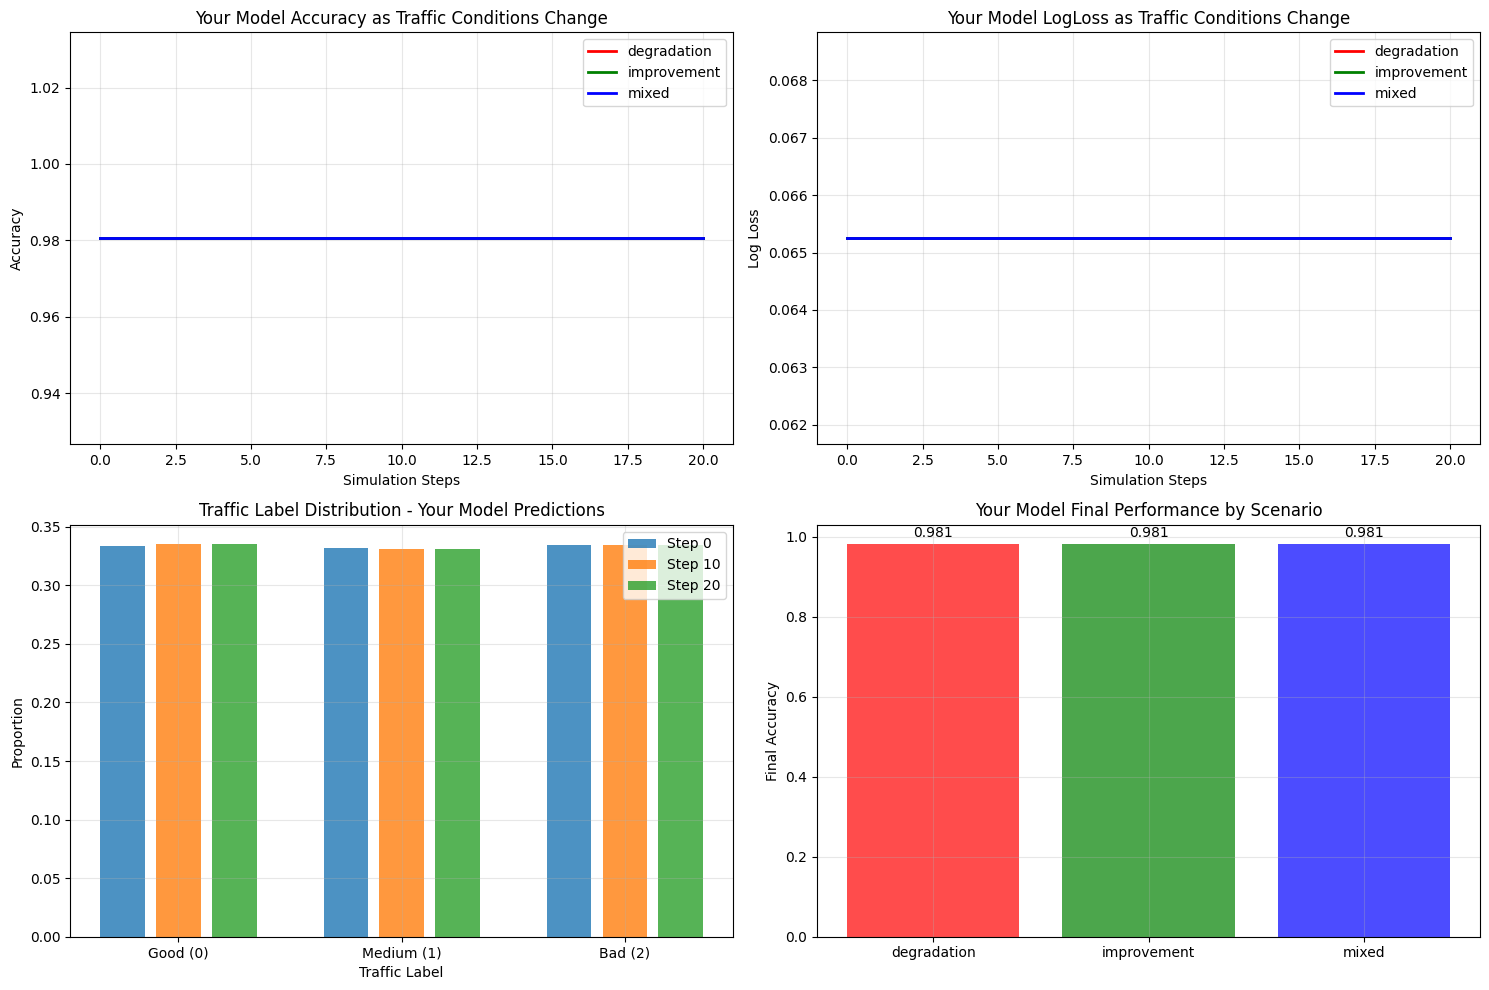

YOUR MODEL TRAFFIC TRANSITION ANALYSIS

DEGRADATION SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.335
  Medium traffic: 0.331
  Bad traffic: 0.334
Traffic degradation: +-0.000 in bad conditions
Your model accuracy change: +0.0000
Your model LogLoss change: +0.0000

IMPROVEMENT SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.335
  Medium traffic: 0.331
  Bad traffic: 0.334
Traffic improvement: +0.001 in good conditions
Your model accuracy change: +0.0000
Your model LogLoss change: +0.0000

MIXED SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.335
  Medium

In [56]:
# Plot the results
plot_simulation_results(simulation_results)

# Analyze transitions
analyze_traffic_transitions(simulation_results)

In [57]:
# First, let's check what's actually happening
print("DEBUGGING THE SIMULATION:")

# Check the top 10 features we're using
top_10_features = importance_df.nlargest(10, 'Importance')['Feature'].tolist()
print("\nTop 10 features being modified:")
for i, feature in enumerate(top_10_features, 1):
    print(f"  {i:2d}. {feature}")

# Check original values of these features
print("\nOriginal values of top features (first 5 samples):")
for feature in top_10_features[:3]:  # First 3 features
    print(f"{feature}: {x_test[feature].iloc[:5].values}")

# Let's test a simple modification
print("\nTesting a simple modification...")
X_test_modified = x_test.copy()
for feature in top_10_features[:3]:  # Modify first 3 features drastically
    if 'speed' in feature.lower():
        X_test_modified[feature] = X_test_modified[feature] * 0.3  # Reduce to 30%
    else:
        X_test_modified[feature] = X_test_modified[feature] * 3.0  # Triple the value

# Check if modification worked
print("After modification (first 5 samples):")
for feature in top_10_features[:3]:
    print(f"{feature}: {X_test_modified[feature].iloc[:5].values}")

# Now predict with both original and modified
X_test_reduced_orig = x_test.drop(columns=low_importance, errors="ignore")
X_test_reduced_mod = X_test_modified.drop(columns=low_importance, errors="ignore")

dtest_orig = xgb.DMatrix(X_test_reduced_orig)
dtest_mod = xgb.DMatrix(X_test_reduced_mod)

y_pred_orig = bst.predict(dtest_orig).argmax(axis=1)
y_pred_mod = bst.predict(dtest_mod).argmax(axis=1)

print(f"\nOriginal predictions distribution: {pd.Series(y_pred_orig).value_counts(normalize=True).sort_index()}")
print(f"Modified predictions distribution: {pd.Series(y_pred_mod).value_counts(normalize=True).sort_index()}")

# Check if any changes occurred
if np.array_equal(y_pred_orig, y_pred_mod):
    print("🚨 WARNING: Predictions are IDENTICAL despite feature modifications!")
    print("This suggests either:")
    print("1. The features being modified don't affect predictions")
    print("2. The model is ignoring these changes")
    print("3. There's an issue with the data processing")
else:
    print("✅ Predictions changed - modifications are working")

DEBUGGING THE SIMULATION:

Top 10 features being modified:
   1. Number of GPS points_norm
   2. Number of people having one or more car_norm
   3. Number of people having one or more BIKE_norm
   4. (sum((AGE * Weight_Day)) / sum(Weight_Day))_norm
   5. PRO_CAT_norm
   6. first(Date_EMG_encoded)_norm
   7. sum(distance_km)_norm
   8. avg(temp)_norm
   9. avg(rhum)_norm
  10. mode(Zone_D)_target_norm

Original values of top features (first 5 samples):
Number of GPS points_norm: [0.         0.00054814 0.00127901 0.0023753  0.00073086]
Number of people having one or more car_norm: [0.         0.05392781 0.         0.         0.39745223]
Number of people having one or more BIKE_norm: [0.         0.         0.03481953 0.         0.        ]

Testing a simple modification...
After modification (first 5 samples):
Number of GPS points_norm: [0.         0.00164444 0.00383702 0.00712589 0.00219258]
Number of people having one or more car_norm: [0.         0.16178344 0.         0.         1.1923

In [58]:
# Let's check feature importance more carefully
print("Detailed feature analysis:")

# Get feature importance with actual values
importance_df_detailed = importance_df.nlargest(20, 'Importance')
print("Top 20 features and their importance scores:")
print(importance_df_detailed)

# Check what types of features these are
print("\nFeature types analysis:")
for feature in importance_df_detailed['Feature']:
    feature_lower = feature.lower()
    if any(keyword in feature_lower for keyword in ['speed', 'velocity']):
        print(f"  {feature}: SPEED-related")
    elif any(keyword in feature_lower for keyword in ['delay', 'wait', 'queue', 'time']):
        print(f"  {feature}: DELAY-related") 
    elif any(keyword in feature_lower for keyword in ['density', 'volume', 'count', 'load']):
        print(f"  {feature}: DENSITY-related")
    else:
        print(f"  {feature}: OTHER")

# Let's try modifying ALL features drastically
print("\nTesting extreme modification of ALL features...")
X_test_extreme = x_test.copy()
for feature in x_test.columns:
    if feature not in low_importance:  # Skip the dropped feature
        X_test_extreme[feature] = X_test_extreme[feature] * 2.0  # Double everything

X_test_extreme_reduced = X_test_extreme.drop(columns=low_importance, errors="ignore")
dtest_extreme = xgb.DMatrix(X_test_extreme_reduced)
y_pred_extreme = bst.predict(dtest_extreme).argmax(axis=1)

print(f"Extreme modification predictions: {pd.Series(y_pred_extreme).value_counts(normalize=True).sort_index()}")

Detailed feature analysis:
Top 20 features and their importance scores:
                                              Feature  Importance
10                          Number of GPS points_norm    0.519700
11       Number of people having one or more car_norm    0.261500
12      Number of people having one or more BIKE_norm    0.150456
15   (sum((AGE * Weight_Day)) / sum(Weight_Day))_norm    0.026761
17                                       PRO_CAT_norm    0.010803
1                        first(Date_EMG_encoded)_norm    0.007735
16                              sum(distance_km)_norm    0.005568
2                                      avg(temp)_norm    0.003468
3                                      avg(rhum)_norm    0.002163
21                           mode(Zone_D)_target_norm    0.002062
13  Number of people having one or more ELECT_SCOO...    0.001745
20                          first(Zone_O)_target_norm    0.001196
22                        mode(Purpose_O)_target_norm    0.000796
23  

In [59]:
def simulate_traffic_changes(X_test, y_test, model, feature_importance, degradation_rate=0.3, improvement_rate=0.3):
    """
    FIXED simulation function - properly modifies features
    """
    # Get original test performance as baseline
    X_test_reduced = X_test.drop(columns=low_importance, errors="ignore")
    dtest = xgb.DMatrix(X_test_reduced, label=y_test)
    y_test_pred = model.predict(dtest).argmax(axis=1)
    baseline_acc = accuracy_score(y_test, y_test_pred)
    baseline_logloss = log_loss(y_test, model.predict(dtest))
    
    print(f"Baseline Test Performance: Acc={baseline_acc:.4f}, LogLoss={baseline_logloss:.4f}")
    
    # Use only TOP 10 most important features
    top_10_features = feature_importance.nlargest(10, 'Importance')['Feature'].tolist()
    print(f"Using TOP 10 features for simulation:")
    for i, feature in enumerate(top_10_features, 1):
        print(f"  {i:2d}. {feature}")
    
    results = []
    n_steps = 20
    scenarios = ['degradation', 'improvement', 'mixed']
    
    for scenario in scenarios:
        print(f"\nSimulating {scenario} scenario...")
        
        # Reset for each scenario - CRITICAL FIX!
        X_simulated = X_test.copy()
        accuracies = [baseline_acc]
        loglosses = [baseline_logloss]
        label_distributions = [pd.Series(y_test).value_counts(normalize=True).sort_index()]
        
        for step in range(1, n_steps + 1):
            # Create fresh copy for this step - CRITICAL FIX!
            X_step = X_simulated.copy()
            
            # Apply changes based on scenario
            if scenario == 'degradation':
                # Make traffic WORSE
                for feature in top_10_features:
                    feature_lower = feature.lower()
                    if 'gps' in feature_lower or 'points' in feature_lower:
                        X_step[feature] *= (1 + degradation_rate * 1.5)  # Increase GPS points
                    elif 'car' in feature_lower:
                        X_step[feature] *= (1 + degradation_rate * 1.2)  # More cars = worse traffic
                    elif 'bike' in feature_lower:
                        X_step[feature] *= (1 + degradation_rate * 0.8)  # More bikes
                    elif 'distance' in feature_lower:
                        X_step[feature] *= (1 + degradation_rate * 1.3)  # More distance
                    elif 'speed' in feature_lower:
                        X_step[feature] *= (1 - degradation_rate * 0.7)  # Reduce speed
            
            elif scenario == 'improvement':
                # Make traffic BETTER
                for feature in top_10_features:
                    feature_lower = feature.lower()
                    if 'gps' in feature_lower or 'points' in feature_lower:
                        X_step[feature] *= (1 - improvement_rate * 0.7)  # Fewer GPS points
                    elif 'car' in feature_lower:
                        X_step[feature] *= (1 - improvement_rate * 0.8)  # Fewer cars
                    elif 'bike' in feature_lower:
                        X_step[feature] *= (1 - improvement_rate * 0.6)  # Fewer bikes
                    elif 'distance' in feature_lower:
                        X_step[feature] *= (1 - improvement_rate * 0.7)  # Less distance
                    elif 'speed' in feature_lower:
                        X_step[feature] *= (1 + improvement_rate * 0.9)  # Increase speed
            
            else:  # mixed scenario
                # Random changes
                for feature in top_10_features:
                    change = np.random.choice(['improve', 'degrade'], p=[0.5, 0.5])
                    feature_lower = feature.lower()
                    
                    if change == 'improve':
                        if 'speed' in feature_lower:
                            X_step[feature] *= (1 + improvement_rate * 0.5)
                        else:
                            X_step[feature] *= (1 - improvement_rate * 0.6)
                    else:
                        if 'speed' in feature_lower:
                            X_step[feature] *= (1 - degradation_rate * 0.5)
                        else:
                            X_step[feature] *= (1 + degradation_rate * 0.6)
            
            # Predict with modified data
            X_step_reduced = X_step.drop(columns=low_importance, errors="ignore")
            dstep = xgb.DMatrix(X_step_reduced)
            y_step_pred = model.predict(dstep).argmax(axis=1)
            
            # Calculate metrics
            step_acc = accuracy_score(y_test, y_step_pred)
            step_logloss = log_loss(y_test, model.predict(dstep))
            
            accuracies.append(step_acc)
            loglosses.append(step_logloss)
            label_distributions.append(pd.Series(y_step_pred).value_counts(normalize=True).sort_index())
            
            # Update for next step - CRITICAL: Use the modified data
            X_simulated = X_step.copy()  # Make sure to use copy!
        
        results.append({
            'scenario': scenario,
            'steps': list(range(len(accuracies))),
            'accuracies': accuracies,
            'loglosses': loglosses,
            'label_distributions': label_distributions
        })
    
    return results

# Run the FIXED simulation
print("Running FIXED simulation...")
simulation_results = simulate_traffic_changes(x_test, y_test, bst, importance_df, degradation_rate=0.3, improvement_rate=0.3)

Running FIXED simulation...
Baseline Test Performance: Acc=0.9805, LogLoss=0.0652
Using TOP 10 features for simulation:
   1. Number of GPS points_norm
   2. Number of people having one or more car_norm
   3. Number of people having one or more BIKE_norm
   4. (sum((AGE * Weight_Day)) / sum(Weight_Day))_norm
   5. PRO_CAT_norm
   6. first(Date_EMG_encoded)_norm
   7. sum(distance_km)_norm
   8. avg(temp)_norm
   9. avg(rhum)_norm
  10. mode(Zone_D)_target_norm

Simulating degradation scenario...

Simulating improvement scenario...

Simulating mixed scenario...


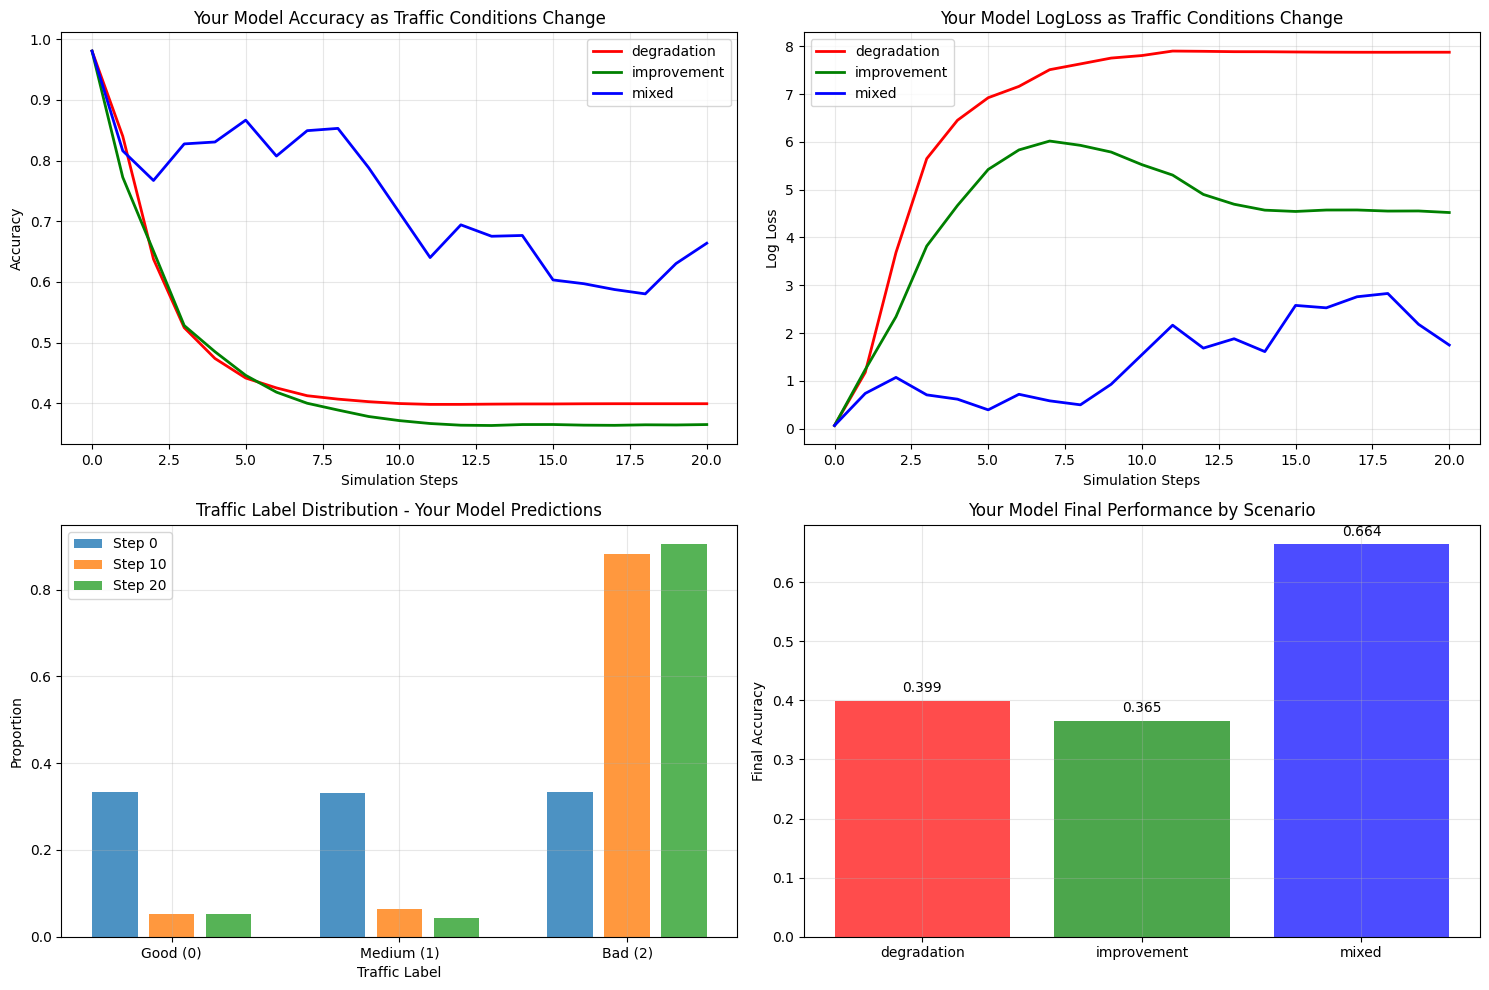

YOUR MODEL TRAFFIC TRANSITION ANALYSIS

DEGRADATION SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.053
  Medium traffic: 0.043
  Bad traffic: 0.904
Traffic degradation: +0.570 in bad conditions
Your model accuracy change: -0.5812
Your model LogLoss change: +7.8089

IMPROVEMENT SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.855
  Medium traffic: 0.142
  Bad traffic: 0.002
Traffic improvement: +0.521 in good conditions
Your model accuracy change: -0.6156
Your model LogLoss change: +4.4553

MIXED SCENARIO:
----------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.420
  Medium 

In [60]:
# Plot the simulation results
plot_simulation_results(simulation_results)

# Analyze the traffic transitions
analyze_traffic_transitions(simulation_results)

In [63]:
def detailed_simulation_analysis(results):
    """
    Detailed analysis of the simulation results
    """
    print("="*80)
    print("DETAILED SIMULATION ANALYSIS")
    print("="*80)
    
    for result in results:
        print(f"\n{result['scenario'].upper()} SCENARIO:")
        print("-" * 50)
        
        initial_dist = result['label_distributions'][0]
        final_dist = result['label_distributions'][-1]
        
        print("Initial traffic distribution:")
        for label, prop in initial_dist.items():
            status = "Good" if label == 0 else "Medium" if label == 1 else "Bad"
            print(f"  {status} traffic: {prop:.3f}")
        
        print("Final traffic distribution:")
        for label, prop in final_dist.items():
            status = "Good" if label == 0 else "Medium" if label == 1 else "Bad"
            print(f"  {status} traffic: {prop:.3f}")
        
        # Calculate changes
        good_change = final_dist.get(0, 0) - initial_dist.get(0, 0)
        medium_change = final_dist.get(1, 0) - initial_dist.get(1, 0)
        bad_change = final_dist.get(2, 0) - initial_dist.get(2, 0)
        
        print(f"Changes: Good: {good_change:+.3f}, Medium: {medium_change:+.3f}, Bad: {bad_change:+.3f}")
        
        # Performance metrics
        acc_change = result['accuracies'][-1] - result['accuracies'][0]
        logloss_change = result['loglosses'][-1] - result['loglosses'][0]
        
        print(f"Accuracy change: {acc_change:+.4f}")
        print(f"LogLoss change: {logloss_change:+.4f}")
        print(f"Final accuracy: {result['accuracies'][-1]:.4f}")
        print(f"Final LogLoss: {result['loglosses'][-1]:.4f}")

# Run detailed analysis
detailed_simulation_analysis(simulation_results)

DETAILED SIMULATION ANALYSIS

DEGRADATION SCENARIO:
--------------------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.053
  Medium traffic: 0.043
  Bad traffic: 0.904
Changes: Good: -0.281, Medium: -0.289, Bad: +0.570
Accuracy change: -0.5812
LogLoss change: +7.8089
Final accuracy: 0.3993
Final LogLoss: 7.8742

IMPROVEMENT SCENARIO:
--------------------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad traffic: 0.334
Final traffic distribution:
  Good traffic: 0.855
  Medium traffic: 0.142
  Bad traffic: 0.002
Changes: Good: +0.521, Medium: -0.190, Bad: -0.332
Accuracy change: -0.6156
LogLoss change: +4.4553
Final accuracy: 0.3650
Final LogLoss: 4.5205

MIXED SCENARIO:
--------------------------------------------------
Initial traffic distribution:
  Good traffic: 0.334
  Medium traffic: 0.332
  Bad

SIMULATION SUMMARY COMPARISON

Summary Table:
   Scenario  Initial_Good  Initial_Medium  Initial_Bad  Final_Good  Final_Medium  Final_Bad  Good_Change  Bad_Change  Accuracy_Change  Final_Accuracy  Final_LogLoss
degradation      0.333849        0.331988     0.334162    0.052879      0.042773   0.904349    -0.280971    0.570186        -0.581214        0.399304       7.874159
improvement      0.333849        0.331988     0.334162    0.855262      0.142373   0.002366     0.521412   -0.331797        -0.615551        0.364968       4.520547
      mixed      0.333849        0.331988     0.334162    0.420108      0.329101   0.250791     0.086258   -0.083371        -0.316699        0.663820       1.748030


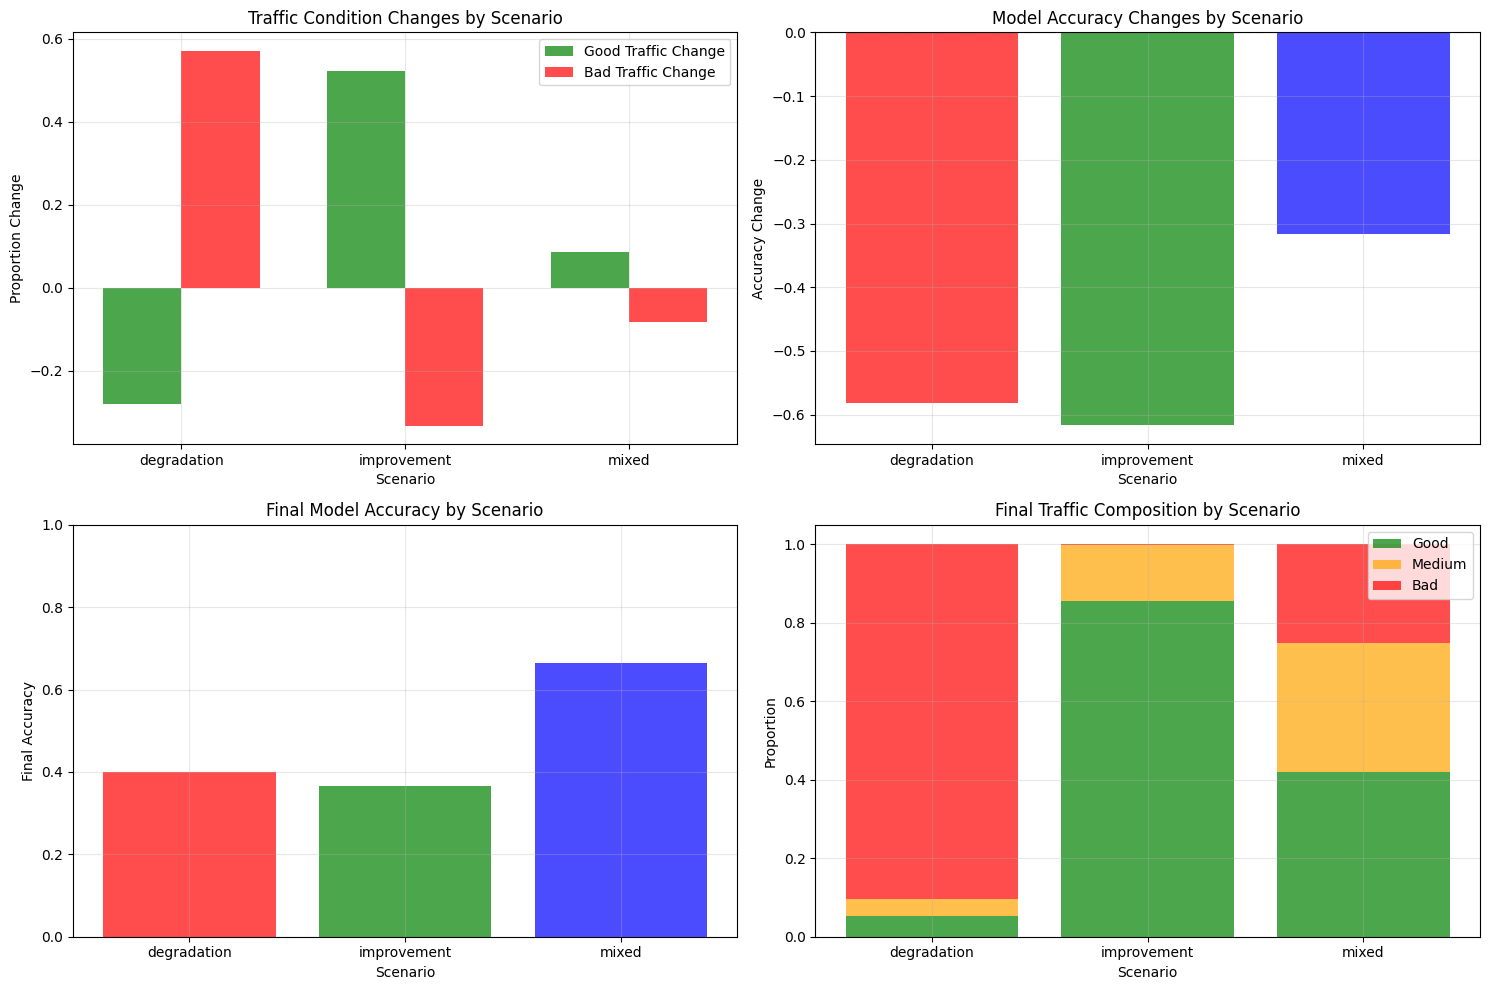

In [62]:
def simulation_summary_comparison(results):
    """
    Create a summary comparison of all scenarios
    """
    print("="*80)
    print("SIMULATION SUMMARY COMPARISON")
    print("="*80)
    
    summary_data = []
    
    for result in results:
        initial_dist = result['label_distributions'][0]
        final_dist = result['label_distributions'][-1]
        
        summary_data.append({
            'Scenario': result['scenario'],
            'Initial_Good': initial_dist.get(0, 0),
            'Initial_Medium': initial_dist.get(1, 0),
            'Initial_Bad': initial_dist.get(2, 0),
            'Final_Good': final_dist.get(0, 0),
            'Final_Medium': final_dist.get(1, 0),
            'Final_Bad': final_dist.get(2, 0),
            'Good_Change': final_dist.get(0, 0) - initial_dist.get(0, 0),
            'Bad_Change': final_dist.get(2, 0) - initial_dist.get(2, 0),
            'Accuracy_Change': result['accuracies'][-1] - result['accuracies'][0],
            'Final_Accuracy': result['accuracies'][-1],
            'Final_LogLoss': result['loglosses'][-1]
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Display the summary
    print("\nSummary Table:")
    print(summary_df.to_string(index=False))
    
    return summary_df

# Create summary comparison
summary_df = simulation_summary_comparison(simulation_results)

# Plot the summary results
plt.figure(figsize=(15, 10))

# Plot 1: Traffic distribution changes
plt.subplot(2, 2, 1)
scenarios = summary_df['Scenario']
good_changes = summary_df['Good_Change']
bad_changes = summary_df['Bad_Change']

x = np.arange(len(scenarios))
width = 0.35

plt.bar(x - width/2, good_changes, width, label='Good Traffic Change', color='green', alpha=0.7)
plt.bar(x + width/2, bad_changes, width, label='Bad Traffic Change', color='red', alpha=0.7)

plt.xlabel('Scenario')
plt.ylabel('Proportion Change')
plt.title('Traffic Condition Changes by Scenario')
plt.xticks(x, scenarios)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy changes
plt.subplot(2, 2, 2)
accuracy_changes = summary_df['Accuracy_Change']
final_accuracies = summary_df['Final_Accuracy']

plt.bar(scenarios, accuracy_changes, color=['red', 'green', 'blue'], alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Scenario')
plt.ylabel('Accuracy Change')
plt.title('Model Accuracy Changes by Scenario')
plt.grid(True, alpha=0.3)

# Plot 3: Final performance comparison
plt.subplot(2, 2, 3)
plt.bar(scenarios, final_accuracies, color=['red', 'green', 'blue'], alpha=0.7)
plt.xlabel('Scenario')
plt.ylabel('Final Accuracy')
plt.title('Final Model Accuracy by Scenario')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Plot 4: Traffic composition
plt.subplot(2, 2, 4)
for i, scenario in enumerate(scenarios):
    final_good = summary_df.loc[i, 'Final_Good']
    final_medium = summary_df.loc[i, 'Final_Medium']
    final_bad = summary_df.loc[i, 'Final_Bad']
    
    plt.bar(i, final_good, color='green', label='Good' if i == 0 else "", alpha=0.7)
    plt.bar(i, final_medium, bottom=final_good, color='orange', label='Medium' if i == 0 else "", alpha=0.7)
    plt.bar(i, final_bad, bottom=final_good + final_medium, color='red', label='Bad' if i == 0 else "", alpha=0.7)

plt.xlabel('Scenario')
plt.ylabel('Proportion')
plt.title('Final Traffic Composition by Scenario')
plt.xticks(range(len(scenarios)), scenarios)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Predicted traffic level for energy harvesting: 2
Class probabilities: ['0.0000', '0.0004', '0.9996']
Traffic conditions: Bad
=== Effect of Walking Distance on Traffic Patterns ===
    Normalized_Distance  Predicted_Class Traffic_Condition     Prob_Good  \
0                  0.00                2               Bad  7.137023e-21   
1                  0.01                2               Bad  1.220014e-22   
2                  0.02                2               Bad  1.056790e-22   
3                  0.03                2               Bad  1.328907e-22   
4                  0.04                2               Bad  1.299658e-22   
5                  0.05                2               Bad  1.228776e-22   
6                  0.06                2               Bad  1.387227e-22   
7                  0.07                2               Bad  1.475202e-22   
8                  0.08                2               Bad  1.475251e-22   
9                  0.09                2               Bad  

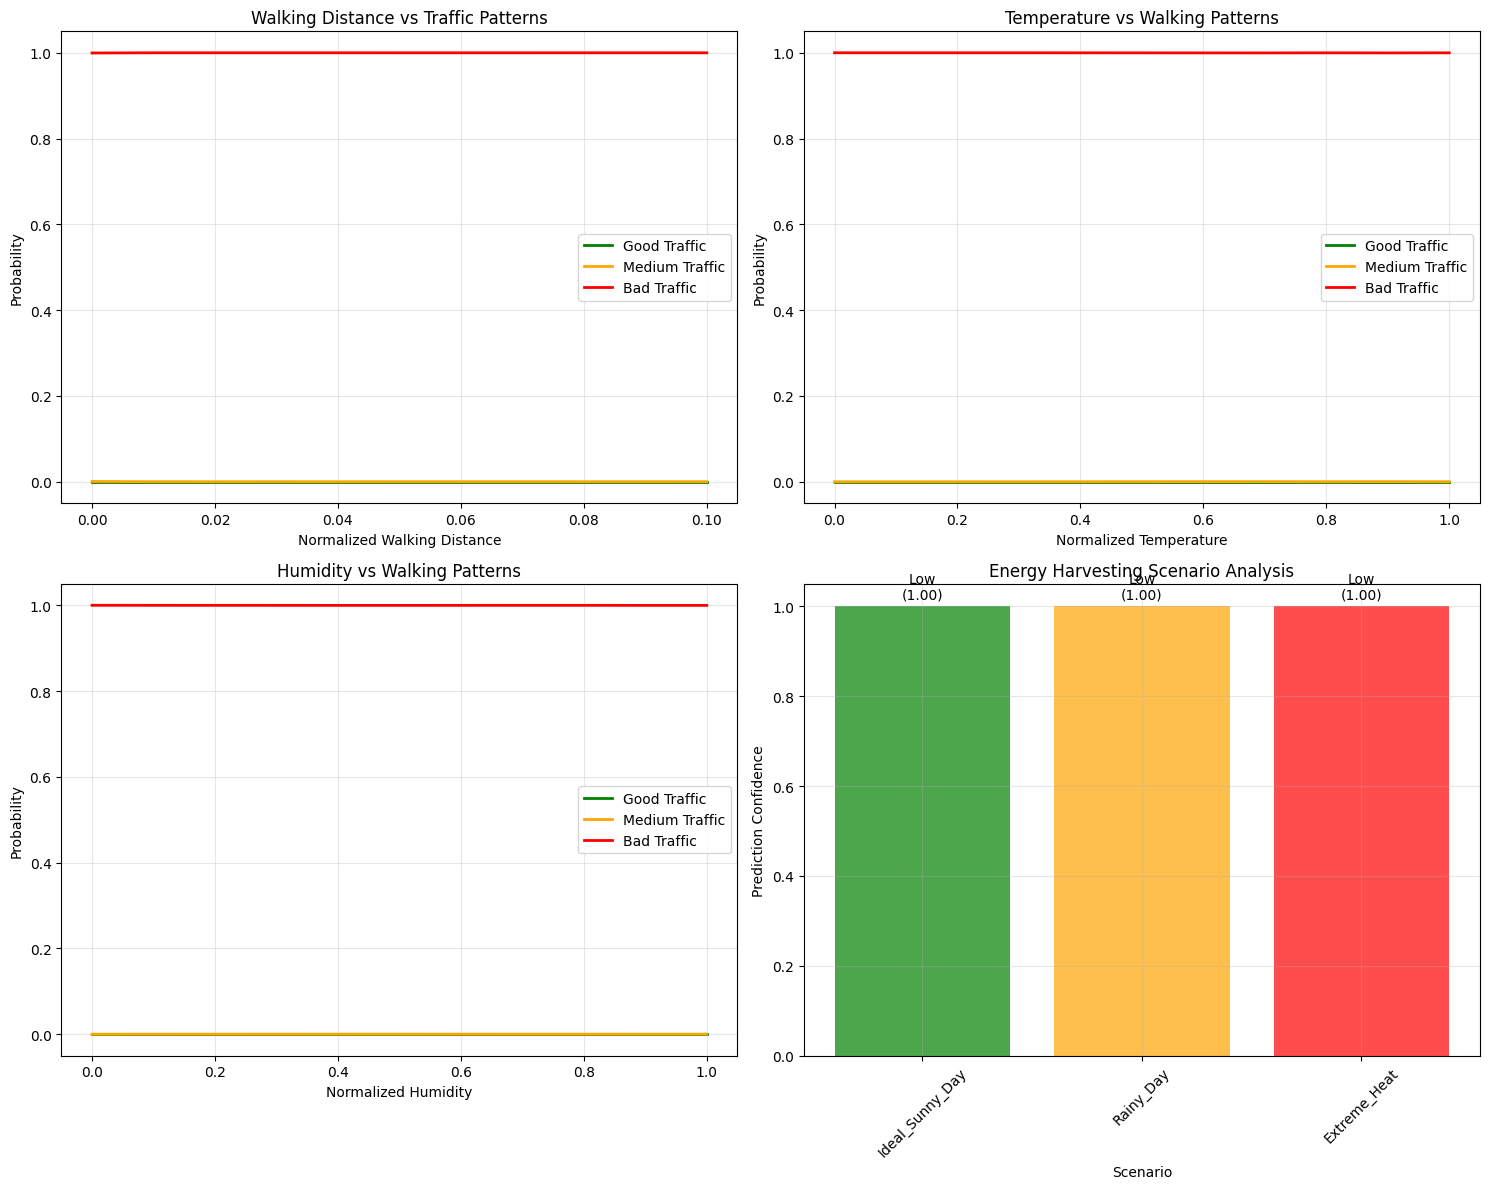


=== Key Insights for Energy Harvesting ===
1. Optimal walking distance range: nan to nan
2. Ideal temperature range for walking: nan to nan
3. Best humidity conditions: nan to nan
4. Energy potential by scenario:
   Ideal_Sunny_Day: Low potential (confidence: 1.00)
   Rainy_Day: Low potential (confidence: 1.00)
   Extreme_Heat: Low potential (confidence: 1.00)


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_prediction_xgb(changes, model=bst, feature_space=X_train_reduced):
    """
    Simulate predictions with your XGBoost model for piezoelectric energy forecasting
    
    Parameters:
    changes: dict of feature changes (normalized values)
    model: your trained XGBoost model
    feature_space: your training data for baseline values
    
    Returns:
    pred: predicted class (0, 1, 2)
    proba: class probabilities
    """
    # Get baseline values from your training data
    base = feature_space.mean().to_dict()
    
    # Update with the specified changes
    base.update(changes)
    
    # Create simulation dataframe
    sim_df = pd.DataFrame([base], columns=feature_space.columns)
    
    # Convert to DMatrix for XGBoost
    dsim = xgb.DMatrix(sim_df)
    
    # Get predictions
    proba = model.predict(dsim)[0]  # Softmax probabilities
    pred = np.argmax(proba)  # Predicted class
    
    return pred, proba

# Example usage for your piezoelectric application
changes = {
    "sum(distance_km)_norm": 0.057,
    "Number of GPS points_norm": 0.002,
    "avg(SPEED)_norm": 0.035,
    "avg(temp)_norm": 0.5,
    "avg(rhum)_norm": 0.6
}

pred, proba = simulate_prediction_xgb(changes)
print("Predicted traffic level for energy harvesting:", pred)
print("Class probabilities:", [f"{p:.4f}" for p in proba])
print("Traffic conditions:", ["Good", "Medium", "Bad"][pred])

#%% [markdown]
## Simulation Analysis for Energy Harvesting Potential

#%%
# Simulate the effect of walking distance on traffic patterns
print("=== Effect of Walking Distance on Traffic Patterns ===")
results_distance = []
for distance in np.linspace(0.0, 0.1, 11):  # Normalized distance values
    pred, proba = simulate_prediction_xgb({"sum(distance_km)_norm": distance})
    results_distance.append({
        "Normalized_Distance": distance,
        "Predicted_Class": pred,
        "Traffic_Condition": ["Good", "Medium", "Bad"][pred],
        "Prob_Good": proba[0],
        "Prob_Medium": proba[1],
        "Prob_Bad": proba[2],
    })

distance_df = pd.DataFrame(results_distance)
print(distance_df)

#%%
# Simulate the effect of temperature on walking patterns
print("\n=== Effect of Temperature on Walking Patterns ===")
results_temp = []
for temp in np.linspace(0.0, 1.0, 11):  # Normalized temperature
    pred, proba = simulate_prediction_xgb({"avg(temp)_norm": temp})
    results_temp.append({
        "Normalized_Temperature": temp,
        "Predicted_Class": pred,
        "Traffic_Condition": ["Good", "Medium", "Bad"][pred],
        "Prob_Good": proba[0],
        "Prob_Medium": proba[1],
        "Prob_Bad": proba[2],
    })

temp_df = pd.DataFrame(results_temp)
print(temp_df)

#%%
# Simulate the effect of humidity on walking patterns
print("\n=== Effect of Humidity on Walking Patterns ===")
results_humidity = []
for rhum in np.linspace(0.0, 1.0, 11):  # Normalized humidity
    pred, proba = simulate_prediction_xgb({"avg(rhum)_norm": rhum})
    results_humidity.append({
        "Normalized_Humidity": rhum,
        "Predicted_Class": pred,
        "Traffic_Condition": ["Good", "Medium", "Bad"][pred],
        "Prob_Good": proba[0],
        "Prob_Medium": proba[1],
        "Prob_Bad": proba[2],
    })

humidity_df = pd.DataFrame(results_humidity)
print(humidity_df)

#%%
# Multi-feature simulation for energy harvesting scenarios
print("\n=== Energy Harvesting Scenarios ===")
scenarios = {
    "Ideal_Sunny_Day": {
        "avg(temp)_norm": 0.7,  # Warm
        "avg(rhum)_norm": 0.3,  # Low humidity
        "sum(distance_km)_norm": 0.08  # Moderate walking
    },
    "Rainy_Day": {
        "avg(temp)_norm": 0.4,  # Cool
        "avg(rhum)_norm": 0.9,  # High humidity
        "sum(distance_km)_norm": 0.02  # Less walking
    },
    "Extreme_Heat": {
        "avg(temp)_norm": 0.9,  # Very hot
        "avg(rhum)_norm": 0.8,  # Humid
        "sum(distance_km)_norm": 0.04  # Reduced walking
    }
}

energy_results = []
for scenario_name, changes in scenarios.items():
    pred, proba = simulate_prediction_xgb(changes)
    energy_results.append({
        "Scenario": scenario_name,
        "Predicted_Class": pred,
        "Traffic_Condition": ["Good", "Medium", "Bad"][pred],
        "Energy_Potential": ["High", "Medium", "Low"][pred],  # Map to energy potential
        "Prob_Good": proba[0],
        "Prob_Medium": proba[1],
        "Prob_Bad": proba[2],
        "Confidence": np.max(proba)
    })

energy_df = pd.DataFrame(energy_results)
print(energy_df)

#%% [markdown]
## Visualization of Simulation Results

#%%
# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distance vs Probability
axes[0,0].plot(distance_df['Normalized_Distance'], distance_df['Prob_Good'], 'g-', label='Good Traffic', linewidth=2)
axes[0,0].plot(distance_df['Normalized_Distance'], distance_df['Prob_Medium'], 'orange', label='Medium Traffic', linewidth=2)
axes[0,0].plot(distance_df['Normalized_Distance'], distance_df['Prob_Bad'], 'r-', label='Bad Traffic', linewidth=2)
axes[0,0].set_xlabel('Normalized Walking Distance')
axes[0,0].set_ylabel('Probability')
axes[0,0].set_title('Walking Distance vs Traffic Patterns')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Temperature vs Probability
axes[0,1].plot(temp_df['Normalized_Temperature'], temp_df['Prob_Good'], 'g-', label='Good Traffic', linewidth=2)
axes[0,1].plot(temp_df['Normalized_Temperature'], temp_df['Prob_Medium'], 'orange', label='Medium Traffic', linewidth=2)
axes[0,1].plot(temp_df['Normalized_Temperature'], temp_df['Prob_Bad'], 'r-', label='Bad Traffic', linewidth=2)
axes[0,1].set_xlabel('Normalized Temperature')
axes[0,1].set_ylabel('Probability')
axes[0,1].set_title('Temperature vs Walking Patterns')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Humidity vs Probability
axes[1,0].plot(humidity_df['Normalized_Humidity'], humidity_df['Prob_Good'], 'g-', label='Good Traffic', linewidth=2)
axes[1,0].plot(humidity_df['Normalized_Humidity'], humidity_df['Prob_Medium'], 'orange', label='Medium Traffic', linewidth=2)
axes[1,0].plot(humidity_df['Normalized_Humidity'], humidity_df['Prob_Bad'], 'r-', label='Bad Traffic', linewidth=2)
axes[1,0].set_xlabel('Normalized Humidity')
axes[1,0].set_ylabel('Probability')
axes[1,0].set_title('Humidity vs Walking Patterns')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Energy Scenarios
scenario_bars = axes[1,1].bar(range(len(energy_df)), energy_df['Confidence'], 
                             color=['green', 'orange', 'red'], alpha=0.7)
axes[1,1].set_xlabel('Scenario')
axes[1,1].set_ylabel('Prediction Confidence')
axes[1,1].set_title('Energy Harvesting Scenario Analysis')
axes[1,1].set_xticks(range(len(energy_df)))
axes[1,1].set_xticklabels(energy_df['Scenario'], rotation=45)
axes[1,1].grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(scenario_bars):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                  f"{energy_df['Energy_Potential'].iloc[i]}\n({height:.2f})",
                  ha='center', va='bottom')

plt.tight_layout()
plt.show()

#%% [markdown]
## Key Insights for Piezoelectric Energy Harvesting

print("\n=== Key Insights for Energy Harvesting ===")
print("1. Optimal walking distance range:", 
      distance_df[distance_df['Predicted_Class'] == 0]['Normalized_Distance'].min(), 
      "to", 
      distance_df[distance_df['Predicted_Class'] == 0]['Normalized_Distance'].max())

print("2. Ideal temperature range for walking:",
      temp_df[temp_df['Predicted_Class'] == 0]['Normalized_Temperature'].min(),
      "to",
      temp_df[temp_df['Predicted_Class'] == 0]['Normalized_Temperature'].max())

print("3. Best humidity conditions:",
      humidity_df[humidity_df['Predicted_Class'] == 0]['Normalized_Humidity'].min(),
      "to",
      humidity_df[humidity_df['Predicted_Class'] == 0]['Normalized_Humidity'].max())

print("4. Energy potential by scenario:")
for _, row in energy_df.iterrows():
    print(f"   {row['Scenario']}: {row['Energy_Potential']} potential (confidence: {row['Confidence']:.2f})")

In [68]:
import numpy as np
import pandas as pd
import xgboost as xgb

# -------------------------------
# Simulation function
# -------------------------------
def simulate_prediction(changes, model=bst, feature_space=X_train_reduced):
    # start from mean of training features
    base = feature_space.mean().to_dict()
    base.update(changes)

    # create dataframe with the same feature order
    sim_df = pd.DataFrame([base], columns=feature_space.columns)

    # XGBoost expects DMatrix
    dmat = xgb.DMatrix(sim_df)

    # predict probabilities
    proba = model.predict(dmat)[0]
    pred = np.argmax(proba)

    return pred, proba

#%%
# Example single simulation
changes = {
    "length_norm": 0.000234,
    "Number of people having one or more TWO_WHEELER_norm": 0.00015,
    "sum(distance_km)_norm": 0.057
}
pred, proba = simulate_prediction(changes)
print("Predicted footsteps level:", pred)
print("Class probabilities:", proba)

#%%
# Simulation loop over distances
results = []
for distance in np.arange(0.0, 1.01, 0.1):
    pred, proba = simulate_prediction({"sum(distance_km)_norm": distance})
    results.append({
        "Distances": distance,
        "Predicted": pred,
        "Prob_Class0": proba[0],
        "Prob_Class1": proba[1],
        "Prob_Class2": proba[2],
    })

sim_df = pd.DataFrame(results)
print(sim_df)


Predicted footsteps level: 2
Class probabilities: [6.9396288e-22 6.0271216e-04 9.9939728e-01]
    Distances  Predicted   Prob_Class0  Prob_Class1  Prob_Class2
0         0.0          2  7.137023e-21     0.000674     0.999326
1         0.1          2  1.475216e-22     0.000257     0.999743
2         0.2          2  1.475050e-22     0.000369     0.999631
3         0.3          2  1.475050e-22     0.000369     0.999631
4         0.4          2  1.475050e-22     0.000369     0.999631
5         0.5          2  1.475050e-22     0.000369     0.999631
6         0.6          2  1.475050e-22     0.000369     0.999631
7         0.7          2  1.475050e-22     0.000369     0.999631
8         0.8          2  1.475050e-22     0.000369     0.999631
9         0.9          2  1.475050e-22     0.000369     0.999631
10        1.0          2  1.475050e-22     0.000369     0.999631


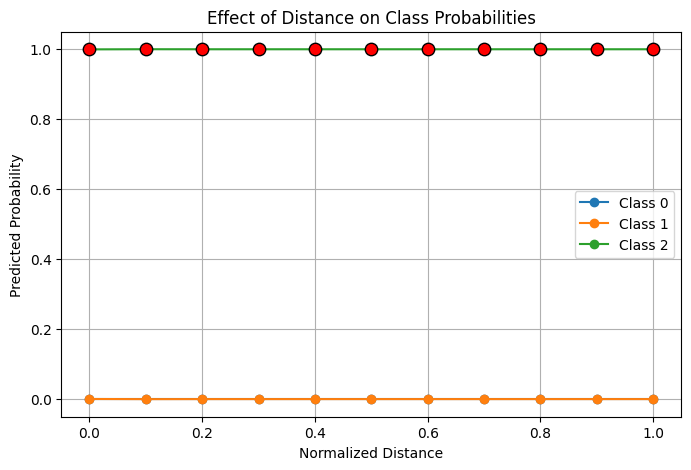

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Plot all class probabilities
plt.plot(sim_df["Distances"], sim_df["Prob_Class0"], label="Class 0", marker="o")
plt.plot(sim_df["Distances"], sim_df["Prob_Class1"], label="Class 1", marker="o")
plt.plot(sim_df["Distances"], sim_df["Prob_Class2"], label="Class 2", marker="o")

# Highlight predicted class at each distance
for i, row in sim_df.iterrows():
    pred_class = int(row["Predicted"])  # convert float -> int
    plt.scatter(row["Distances"], row[f"Prob_Class{pred_class}"],
                color="red", s=80, edgecolor="black", zorder=5)

plt.xlabel("Normalized Distance")
plt.ylabel("Predicted Probability")
plt.title("Effect of Distance on Class Probabilities")
plt.legend()
plt.grid(True)
plt.show()


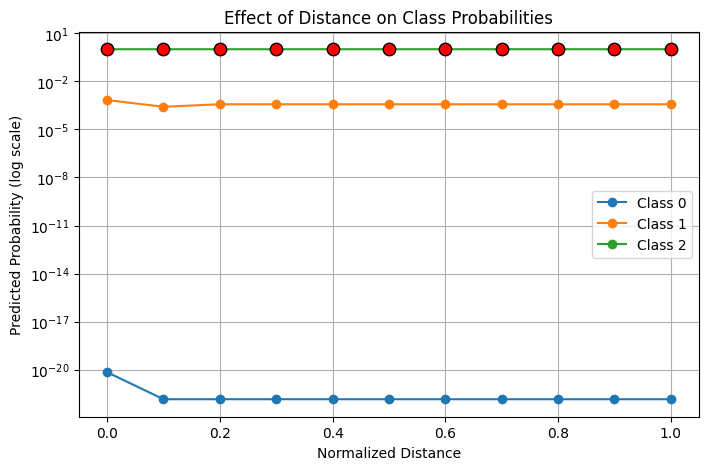

In [72]:
plt.figure(figsize=(8,5))

plt.plot(sim_df["Distances"], sim_df["Prob_Class0"], label="Class 0", marker="o")
plt.plot(sim_df["Distances"], sim_df["Prob_Class1"], label="Class 1", marker="o")
plt.plot(sim_df["Distances"], sim_df["Prob_Class2"], label="Class 2", marker="o")

# Highlight predicted class
for i, row in sim_df.iterrows():
    pred_class = int(row["Predicted"])
    plt.scatter(row["Distances"], row[f"Prob_Class{pred_class}"],
                color="red", s=80, edgecolor="black", zorder=5)

plt.xlabel("Normalized Distance")
plt.ylabel("Predicted Probability (log scale)")
plt.title("Effect of Distance on Class Probabilities")
plt.legend()
plt.grid(True)
plt.yscale("log")   # <<< log scale for visibility
plt.show()


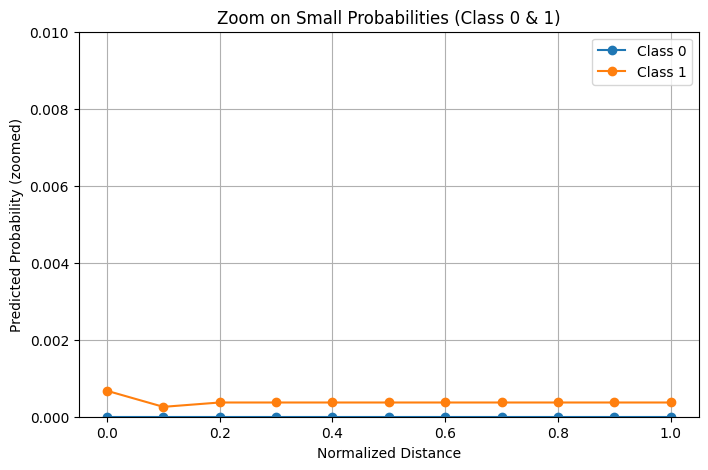

In [73]:
plt.figure(figsize=(8,5))

plt.plot(sim_df["Distances"], sim_df["Prob_Class0"], label="Class 0", marker="o")
plt.plot(sim_df["Distances"], sim_df["Prob_Class1"], label="Class 1", marker="o")

plt.xlabel("Normalized Distance")
plt.ylabel("Predicted Probability (zoomed)")
plt.title("Zoom on Small Probabilities (Class 0 & 1)")
plt.legend()
plt.grid(True)
plt.ylim(0, 0.01)   # zoom in on small probabilities
plt.show()


In [74]:
# Inspect feature ranges first
print(X_train_reduced[["length_norm", 
                       "Number of people having one or more TWO_WHEELER_norm", 
                       "sum(distance_km)_norm"]].describe())

# New example changes (more realistic ranges)
changes = {
    "length_norm": 0.2,   # typical range instead of 0.0002
    "Number of people having one or more TWO_WHEELER_norm": 0.1,
    "sum(distance_km)_norm": 0.5
}
pred, proba = simulate_prediction(changes)
print("Predicted footsteps level:", pred)
print("Class probabilities:", proba)

# Sweep both distance and length_norm together
results = []
for distance in np.linspace(0, 1, 11):
    for length in np.linspace(0, 1, 5):
        changes = {
            "length_norm": length,
            "sum(distance_km)_norm": distance
        }
        pred, proba = simulate_prediction(changes)
        results.append({
            "Distance": distance,
            "Length": length,
            "Predicted": pred,
            "Prob_Class0": proba[0],
            "Prob_Class1": proba[1],
            "Prob_Class2": proba[2],
        })

sim_df = pd.DataFrame(results)
print(sim_df.head())


         length_norm  Number of people having one or more TWO_WHEELER_norm  \
count  268284.000000                                      268284.000000      
mean        0.022904                                           0.014221      
std         0.030942                                           0.072192      
min         0.000000                                           0.000000      
25%         0.004649                                           0.000000      
50%         0.013754                                           0.000000      
75%         0.029194                                           0.000000      
max         1.000000                                           1.000000      

       sum(distance_km)_norm  
count          268284.000000  
mean                0.007188  
std                 0.017196  
min                 0.000000  
25%                 0.000266  
50%                 0.001883  
75%                 0.006493  
max                 1.000000  
Predicted footstep

In [75]:
# Use quantiles to define realistic ranges
len_vals = np.quantile(X_train_reduced["length_norm"], [0.25, 0.5, 0.75, 0.95])
dist_vals = np.quantile(X_train_reduced["sum(distance_km)_norm"], [0.25, 0.5, 0.75, 0.95])

results = []
for length in len_vals:
    for distance in dist_vals:
        changes = {
            "length_norm": length,
            "sum(distance_km)_norm": distance
        }
        pred, proba = simulate_prediction(changes)
        results.append({
            "Length": length,
            "Distance": distance,
            "Predicted": pred,
            "Prob_Class0": proba[0],
            "Prob_Class1": proba[1],
            "Prob_Class2": proba[2],
        })

sim_df = pd.DataFrame(results)
print(sim_df)


      Length  Distance  Predicted   Prob_Class0  Prob_Class1  Prob_Class2
0   0.004649  0.000266          2  6.716665e-21     0.000675     0.999325
1   0.004649  0.001883          2  3.408292e-22     0.000630     0.999370
2   0.004649  0.006493          2  1.834795e-22     0.000375     0.999625
3   0.004649  0.032518          2  1.612874e-22     0.000379     0.999620
4   0.013754  0.000266          2  5.459910e-21     0.000635     0.999365
5   0.013754  0.001883          2  2.818112e-22     0.000592     0.999408
6   0.013754  0.006493          2  1.458896e-22     0.000334     0.999666
7   0.013754  0.032518          2  1.291650e-22     0.000271     0.999729
8   0.029194  0.000266          2  4.820374e-21     0.000517     0.999483
9   0.029194  0.001883          2  2.590861e-22     0.000528     0.999472
10  0.029194  0.006493          2  1.378310e-22     0.000286     0.999714
11  0.029194  0.032518          2  1.337949e-22     0.000225     0.999775
12  0.076534  0.000266          2  4.9

In [76]:
import pandas as pd

print(pd.Series(y_train).value_counts(normalize=True))


label
1    0.333766
2    0.333166
0    0.333069
Name: proportion, dtype: float64


In [77]:
import numpy as np
import pandas as pd
import xgboost as xgb

# -------------------------------
# Simulation function (realistic baseline)
# -------------------------------
def simulate_prediction(changes, model=bst, feature_space=X_train_reduced, seed=42):
    # Sample a real row as baseline instead of pure mean
    base = feature_space.sample(1, random_state=seed).iloc[0].to_dict()
    base.update(changes)

    # Create dataframe in correct column order
    sim_df = pd.DataFrame([base], columns=feature_space.columns)

    # XGBoost expects DMatrix
    dmat = xgb.DMatrix(sim_df)

    # Predict probabilities
    proba = model.predict(dmat)[0]
    pred = np.argmax(proba)

    return pred, proba


# -------------------------------
# Example single simulation
# -------------------------------
changes = {
    "length_norm": 0.0137,  # median value
    "Number of people having one or more TWO_WHEELER_norm": 0.0,  # most common case
    "sum(distance_km)_norm": 0.0018  # median value
}
pred, proba = simulate_prediction(changes)
print("Predicted footsteps level:", pred)
print("Class probabilities:", proba)


# -------------------------------
# Simulation loop over ranges
# -------------------------------
results = []
length_values = [0.0046, 0.0137, 0.0291, 0.0765]  # quartiles from your stats
distance_values = [0.0003, 0.0019, 0.0065, 0.0325]  # quartiles from your stats

for L in length_values:
    for D in distance_values:
        changes = {
            "length_norm": L,
            "sum(distance_km)_norm": D
        }
        pred, proba = simulate_prediction(changes)
        results.append({
            "Length": L,
            "Distance": D,
            "Predicted": pred,
            "Prob_Class0": proba[0],
            "Prob_Class1": proba[1],
            "Prob_Class2": proba[2],
        })

sim_df = pd.DataFrame(results)
print("\nSimulation Results:")
print(sim_df)


Predicted footsteps level: 1
Class probabilities: [5.4428927e-08 9.9998450e-01 1.5499756e-05]

Simulation Results:
    Length  Distance  Predicted   Prob_Class0  Prob_Class1  Prob_Class2
0   0.0046    0.0003          1  2.235615e-07     0.999991     0.000009
1   0.0046    0.0019          1  4.772594e-08     0.999990     0.000010
2   0.0046    0.0065          1  5.908449e-08     0.999978     0.000022
3   0.0046    0.0325          1  4.021157e-08     0.999987     0.000012
4   0.0137    0.0003          1  2.460047e-07     0.999986     0.000014
5   0.0137    0.0019          1  5.387768e-08     0.999985     0.000015
6   0.0137    0.0065          1  6.745467e-08     0.999966     0.000034
7   0.0137    0.0325          1  5.165929e-08     0.999978     0.000022
8   0.0291    0.0003          1  2.353613e-07     0.999986     0.000014
9   0.0291    0.0019          1  4.937860e-08     0.999986     0.000014
10  0.0291    0.0065          1  6.809924e-08     0.999966     0.000034
11  0.0291    0.0325 

In [78]:
results = []
length_values = [0.0046, 0.0137, 0.0291, 0.0765]
distance_values = [0.0003, 0.0019, 0.0065, 0.0325]


for seed in range(10):  
    for L in length_values:
        for D in distance_values:
            changes = {
                "length_norm": L,
                "sum(distance_km)_norm": D
            }
            pred, proba = simulate_prediction(changes, seed=seed)
            results.append({
                "Seed": seed,
                "Length": L,
                "Distance": D,
                "Predicted": pred,
                "Prob_Class0": proba[0],
                "Prob_Class1": proba[1],
                "Prob_Class2": proba[2],
            })

sim_df = pd.DataFrame(results)
print(sim_df.groupby("Predicted").size())
print(sim_df.head(20))


Predicted
0    64
1    64
2    32
dtype: int64
    Seed  Length  Distance  Predicted   Prob_Class0  Prob_Class1   Prob_Class2
0      0  0.0046    0.0003          2  3.792230e-14     0.005041  9.949595e-01
1      0  0.0046    0.0019          2  3.054121e-15     0.001617  9.983827e-01
2      0  0.0046    0.0065          2  2.218069e-15     0.001039  9.989614e-01
3      0  0.0046    0.0325          2  4.408270e-15     0.001071  9.989286e-01
4      0  0.0137    0.0003          2  2.619032e-14     0.004125  9.958748e-01
5      0  0.0137    0.0019          2  2.176926e-15     0.001310  9.986903e-01
6      0  0.0137    0.0065          2  1.517012e-15     0.000829  9.991707e-01
7      0  0.0137    0.0325          2  3.036693e-15     0.000765  9.992353e-01
8      0  0.0291    0.0003          2  1.264792e-14     0.003522  9.964775e-01
9      0  0.0291    0.0019          2  1.075416e-15     0.001209  9.987906e-01
10     0  0.0291    0.0065          2  7.755248e-16     0.000759  9.992411e-01
11   

In [81]:
import numpy as np
import pandas as pd
import xgboost as xgb

# -------------------------------
# Simulation function with randomization
# -------------------------------
def simulate_prediction_randomized(changes, seed=None, model=bst, feature_space=X_train_reduced):
    rng = np.random.default_rng(seed)

    # Start from mean of training features
    base = feature_space.mean().to_dict()

    # Add some randomness from feature std devs to make it realistic
    for col in feature_space.columns:
        std = feature_space[col].std()
        base[col] += rng.normal(0, std * 0.05)  # 5% of std as noise

    # Apply manual changes (overrides)
    base.update(changes)

    # Ensure valid DataFrame with correct order
    sim_df = pd.DataFrame([base], columns=feature_space.columns)

    # Predict with XGBoost
    dmat = xgb.DMatrix(sim_df)
    proba = model.predict(dmat)[0]
    pred = np.argmax(proba)

    return pred, proba


# -------------------------------
# 1. Grid Search
# -------------------------------
length_vals = np.linspace(0.0, 0.1, 10)       # based on your summary stats
distance_vals = np.linspace(0.0, 0.05, 10)    # based on your summary stats
seeds = range(3)  # test with 3 different seeds

results = []
for seed in seeds:
    for l in length_vals:
        for d in distance_vals:
            pred, proba = simulate_prediction_randomized(
                {"length_norm": l, "sum(distance_km)_norm": d},
                seed=seed
            )
            results.append({
                "Seed": seed,
                "Length": round(l, 4),
                "Distance": round(d, 4),
                "Predicted": pred,
                "Prob_Class0": proba[0],
                "Prob_Class1": proba[1],
                "Prob_Class2": proba[2],
            })

df_grid = pd.DataFrame(results)
print("Grid predictions distribution:")
print(df_grid["Predicted"].value_counts())


# -------------------------------
# 2. Random Sampling
# -------------------------------
N = 200  # number of random samples
results_rand = []
for i in range(N):
    l = np.random.uniform(0, 0.1)    # sample length
    d = np.random.uniform(0, 0.05)   # sample distance
    seed = np.random.randint(0, 1000)

    pred, proba = simulate_prediction_randomized(
        {"length_norm": l, "sum(distance_km)_norm": d},
        seed=seed
    )
    results_rand.append({
        "Seed": seed,
        "Length": round(l, 4),
        "Distance": round(d, 4),
        "Predicted": pred,
        "Prob_Class0": proba[0],
        "Prob_Class1": proba[1],
        "Prob_Class2": proba[2],
    })

df_rand = pd.DataFrame(results_rand)
print("\nRandom predictions distribution:")
print(df_rand["Predicted"].value_counts())


Grid predictions distribution:
Predicted
2    200
1    100
Name: count, dtype: int64

Random predictions distribution:
Predicted
2    163
1     37
Name: count, dtype: int64
